In [ ]:
pip install tensorflow


===== PRETRAINING ON HOMO DATA =====
Epoch 1/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 171ms/step - accuracy: 0.4330 - loss: 1.3604 - val_accuracy: 0.2181 - val_loss: 2.8083
Epoch 2/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8627 - loss: 0.3810 - val_accuracy: 0.2026 - val_loss: 6.3584
Epoch 3/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9932 - loss: 0.0444 - val_accuracy: 0.2353 - val_loss: 10.3211
Epoch 4/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9958 - loss: 0.0200 - val_accuracy: 0.2661 - val_loss: 12.3895
Epoch 5/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9988 - loss: 0.0057 - val_accuracy: 0.3636 - val_loss: 11.2241
Epoch 6/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9996 - loss: 0.0028 - val_accuracy: 0.3979 - val_loss: 6.8426
Epoch 7/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9998 - loss: 0.0012 - val_accuracy: 0.5773 - val_loss: 2.5210
Epoch 8/50
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - lo

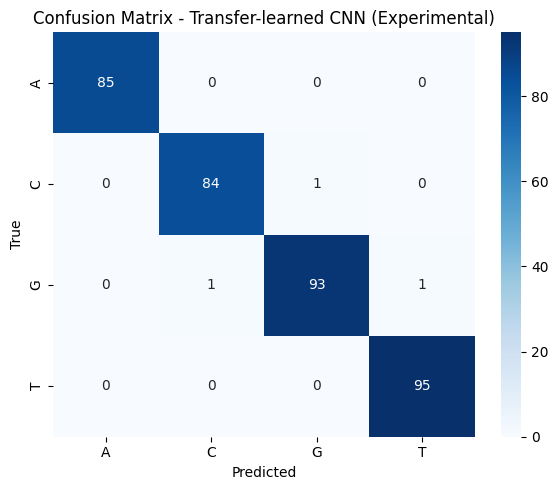

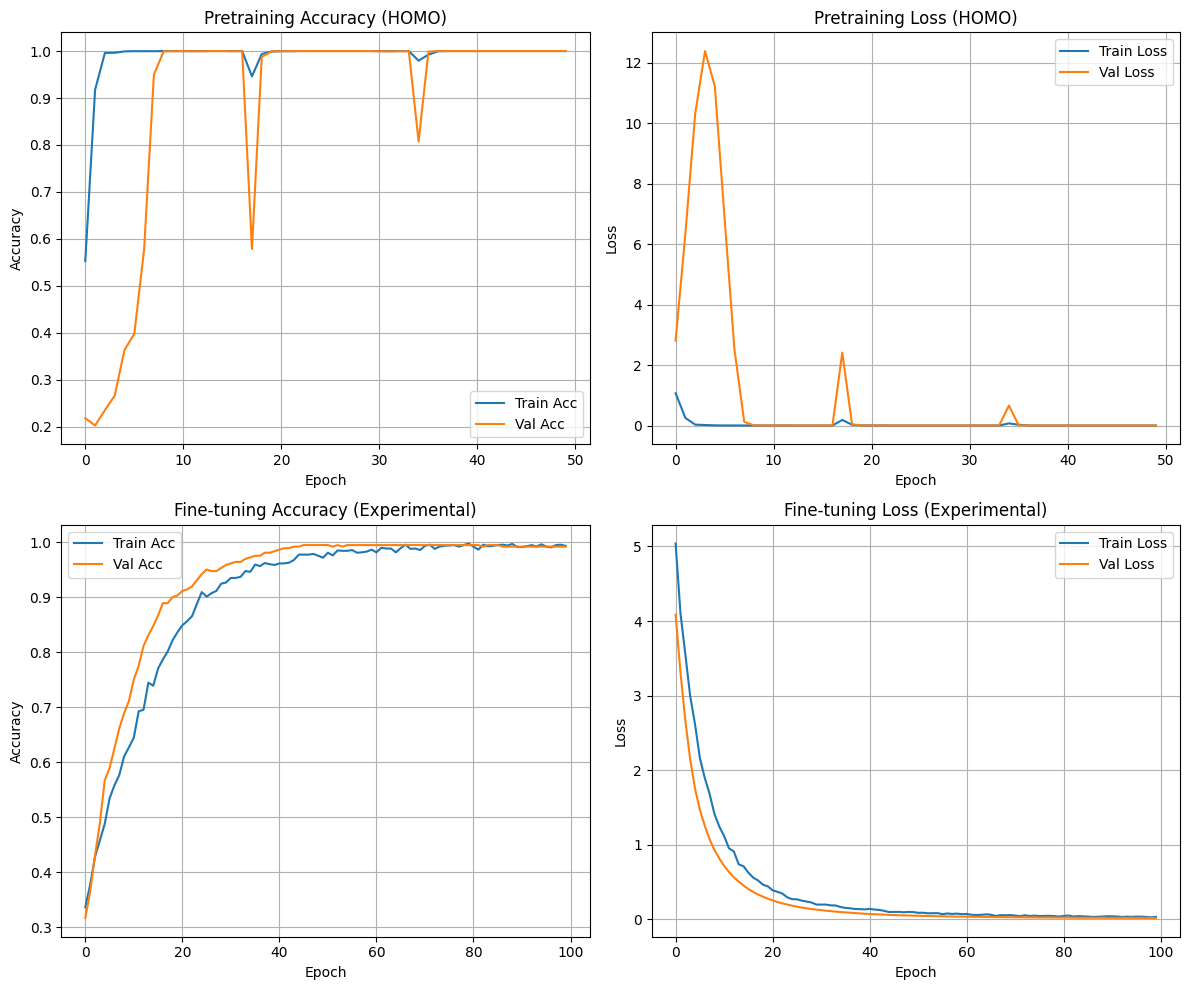

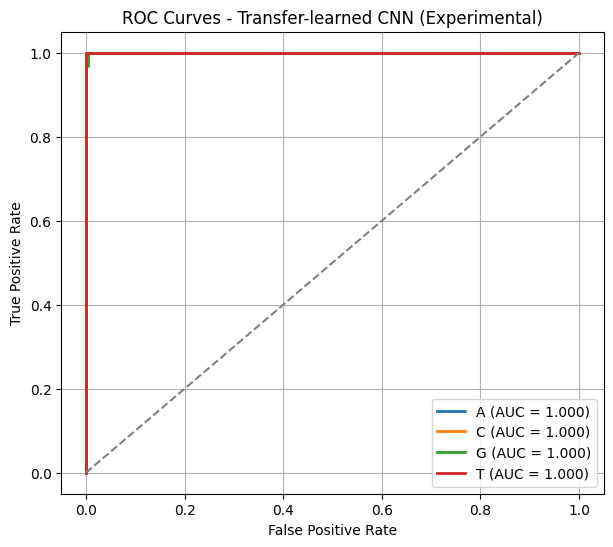

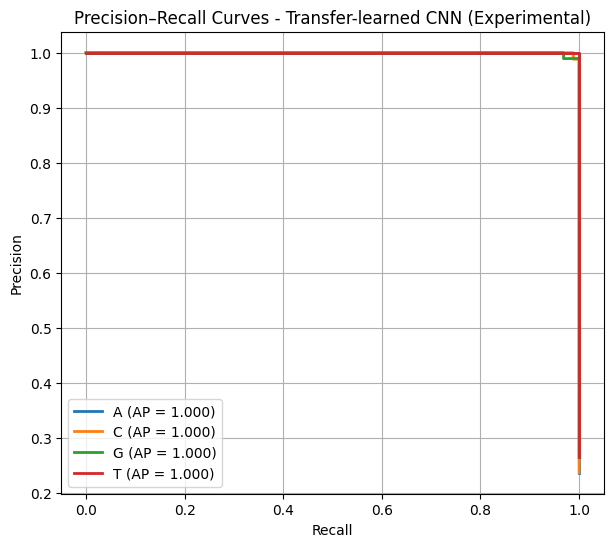

✅ Final Experimental Test Accuracy: 99.17%


In [ ]:
# ============================================================
# 🧬 CNN Transfer Learning Pipeline
# Pretrain on HOMO → Fine-tune on Experimental dataset
# Includes accuracy/loss plots, confusion matrix, ROC, PR curves
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.optimizers import Adam

# -----------------------------
# 1️⃣ Helper: Create sliding windows
# -----------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -----------------------------
# 2️⃣ Load HOMO (Pretraining dataset)
# -----------------------------
homo = pd.read_csv("ML_try1.csv")  # Columns: Current, Target
X_homo, y_homo = create_windows(homo["Current"], homo["Target"], k=101)

# Normalize HOMO
homo_mean, homo_std = X_homo.mean(), X_homo.std()
X_homo = (X_homo - homo_mean) / homo_std
X_homo = X_homo.reshape((X_homo.shape[0], X_homo.shape[1], 1))

encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_homo_oh = tf.keras.utils.to_categorical(y_homo_enc)

X_train, X_val, y_train, y_val = train_test_split(
    X_homo, y_homo_oh, test_size=0.2, random_state=42, stratify=y_homo_enc
)

# -----------------------------
# 3) Build CNN
# -----------------------------
inputs = Input(shape=(X_homo.shape[1], 1))
x = Conv1D(64, 7, activation='relu', name="conv1")(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(128, 7, activation='relu', name="conv2")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(256, 7, activation='relu', name="conv3")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = GlobalAveragePooling1D()(x)
x = Dense(256, activation='relu', name="features")(x)
x = Dropout(0.5)(x)
outputs = Dense(len(encoder.classes_), activation='softmax')(x)

cnn_model = Model(inputs, outputs)
cnn_model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

# -----------------------------
# 4️⃣ Pretrain CNN on HOMO
# -----------------------------
print("\n===== PRETRAINING ON HOMO DATA =====")
history_pretrain = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=1
)

# -----------------------------
# 5️⃣ Load Experimental dataset
# -----------------------------
exp = pd.read_csv("Experimental1.csv")  # Columns: Current, Target
X_exp, y_exp = create_windows(exp["Current"], exp["Target"], k=101)

# Normalize Experimental using HOMO stats
X_exp = (X_exp - homo_mean) / homo_std
X_exp = X_exp.reshape((X_exp.shape[0], X_exp.shape[1], 1))
y_exp_enc = encoder.transform(y_exp)
y_exp_oh = tf.keras.utils.to_categorical(y_exp_enc)

X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp_oh, test_size=0.2, random_state=42, stratify=y_exp_enc
)

# -----------------------------
# 6️⃣ Freeze convolutional layers
# -----------------------------
for layer in cnn_model.layers:
    if isinstance(layer, Conv1D):
        layer.trainable = False

cnn_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# -----------------------------
# 7️⃣ Fine-tune on Experimental dataset
# -----------------------------
print("\n===== TRANSFER LEARNING ON EXPERIMENTAL DATA =====")
history_finetune = cnn_model.fit(
    X_exp_train, y_exp_train,
    validation_data=(X_exp_test, y_exp_test),
    epochs=100,
    batch_size=64,
    verbose=1
)

# -----------------------------
# 8️⃣ Evaluate CNN on Experimental test set
# -----------------------------
y_pred = cnn_model.predict(X_exp_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_exp_test, axis=1)

test_acc = accuracy_score(y_true_labels, y_pred_labels)
print(f"\n✅ Test Accuracy (Experimental, transfer-learned CNN): {test_acc*100:.2f}%\n")

print("=== Classification Report ===")
print(classification_report(y_true_labels, y_pred_labels, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title("Confusion Matrix - Transfer-learned CNN (Experimental)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# -----------------------------
# 9️⃣ Plot training curves (Accuracy + Loss)
# -----------------------------
plt.figure(figsize=(12,10))

# (A) Pretraining accuracy/loss
plt.subplot(2,2,1)
plt.plot(history_pretrain.history['accuracy'], label='Train Acc')
plt.plot(history_pretrain.history['val_accuracy'], label='Val Acc')
plt.title("Pretraining Accuracy (HOMO)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(True)

plt.subplot(2,2,2)
plt.plot(history_pretrain.history['loss'], label='Train Loss')
plt.plot(history_pretrain.history['val_loss'], label='Val Loss')
plt.title("Pretraining Loss (HOMO)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(); plt.grid(True)

# (B) Fine-tuning accuracy/loss
plt.subplot(2,2,3)
plt.plot(history_finetune.history['accuracy'], label='Train Acc')
plt.plot(history_finetune.history['val_accuracy'], label='Val Acc')
plt.title("Fine-tuning Accuracy (Experimental)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(); plt.grid(True)

plt.subplot(2,2,4)
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Val Loss')
plt.title("Fine-tuning Loss (Experimental)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

# -----------------------------
# 🔟 ROC–AUC and Precision–Recall Curves
# -----------------------------
y_test_bin = y_exp_test
n_classes = len(encoder.classes_)

# ROC–AUC
plt.figure(figsize=(7,6))
for i, cls in enumerate(encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{cls} (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC Curves - Transfer-learned CNN (Experimental)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Precision–Recall
plt.figure(figsize=(7,6))
for i, cls in enumerate(encoder.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, lw=2, label=f"{cls} (AP = {ap:.3f})")
plt.title("Precision–Recall Curves - Transfer-learned CNN (Experimental)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# ✅ Final Summary
# -----------------------------
print("==================================================")
print(f"✅ Final Experimental Test Accuracy: {test_acc*100:.2f}%")
print("==================================================")


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.4773 - loss: 1.2585
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9598 - loss: 0.1486
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9946 - loss: 0.0247
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0053
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9994 - loss: 0.0029
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0018
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0015
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 6.3921e-04
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 6.1889e-04
Epoch 10/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.9031e-04
Epoch 11/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 2.4322e-04
Epoch 12/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accu

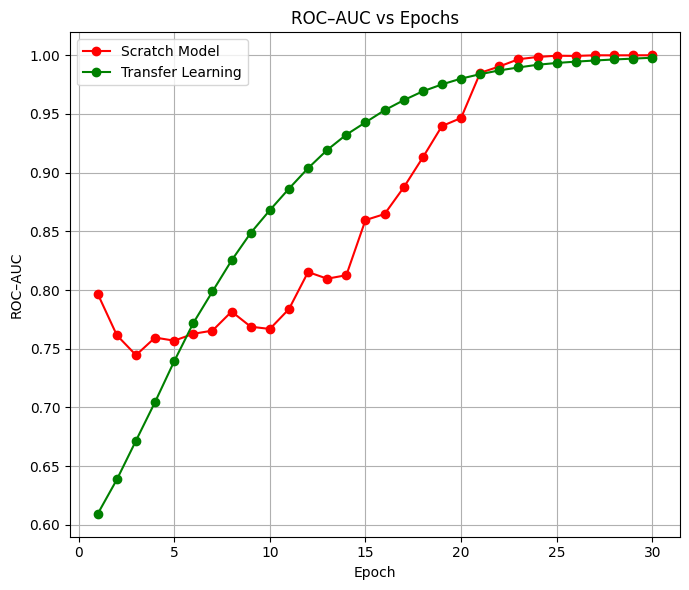

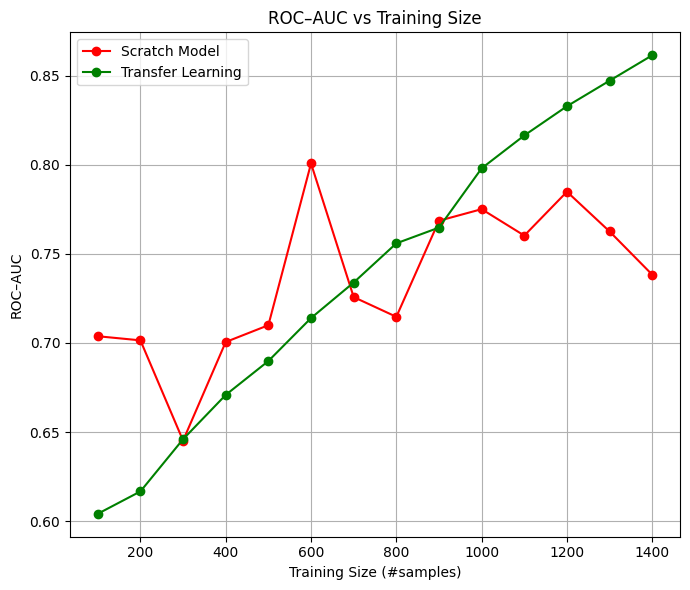

In [ ]:
# ============================================================
# 🧬 Transfer Learning CNN Analysis
# ROC–AUC vs Epochs and Training Size
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Helper: Create sliding windows
# -----------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -----------------------------
# 2️⃣ Load Datasets
# -----------------------------
homo = pd.read_csv("ML_try1.csv")  # HOMO data
exp = pd.read_csv("Experimental1.csv")  # Experimental data

# Create windows
X_homo, y_homo = create_windows(homo["Current"], homo["Target"])
X_exp, y_exp = create_windows(exp["Current"], exp["Target"])

# Normalize using HOMO stats
homo_mean, homo_std = X_homo.mean(), X_homo.std()
X_homo = (X_homo - homo_mean) / homo_std
X_exp = (X_exp - homo_mean) / homo_std

# Reshape for CNN
X_homo = X_homo[..., np.newaxis]
X_exp = X_exp[..., np.newaxis]

# Encode labels
encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_homo_oh = tf.keras.utils.to_categorical(y_homo_enc)
y_exp_enc = encoder.transform(y_exp)
y_exp_oh = tf.keras.utils.to_categorical(y_exp_enc)

# Split experimental into train/test
X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp_oh, test_size=0.2, random_state=42, stratify=y_exp_enc
)

# -----------------------------
# 3️⃣ Define CNN model
# -----------------------------
def build_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 7, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 7, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(256, 7, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# -----------------------------
# 4️⃣ Pretrain on HOMO
# -----------------------------
cnn_pre = build_cnn((X_homo.shape[1], 1), len(encoder.classes_))
cnn_pre.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
cnn_pre.fit(X_homo, y_homo_oh, epochs=20, batch_size=128, verbose=1)
cnn_pre.save_weights("pretrained_homo.weights.h5")

# -----------------------------
# 5️⃣ ROC–AUC vs Epochs (Scratch vs Transfer)
# -----------------------------
epochs = 30
roc_scratch = []
roc_transfer = []

# (a) Scratch model
scratch_model = build_cnn((X_exp.shape[1], 1), len(encoder.classes_))
scratch_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
for e in range(epochs):
    scratch_model.fit(X_exp_train, y_exp_train, epochs=1, batch_size=64, verbose=0)
    y_pred = scratch_model.predict(X_exp_test, verbose=0)
    roc = roc_auc_score(y_exp_test, y_pred, multi_class="ovr")
    roc_scratch.append(roc)

# (b) Transfer learning model
model_tl = build_cnn((X_exp.shape[1], 1), len(encoder.classes_))
model_tl.load_weights("pretrained_homo.weights.h5")

for layer in model_tl.layers:
    if isinstance(layer, Conv1D):
        layer.trainable = False

model_tl.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
for e in range(epochs):
    model_tl.fit(X_exp_train, y_exp_train, epochs=1, batch_size=64, verbose=0)
    y_pred = model_tl.predict(X_exp_test, verbose=0)
    roc = roc_auc_score(y_exp_test, y_pred, multi_class="ovr")
    roc_transfer.append(roc)

# Plot ROC–AUC vs Epochs
plt.figure(figsize=(7,6))
plt.plot(range(1, epochs+1), roc_scratch, 'r-o', label='Scratch Model')
plt.plot(range(1, epochs+1), roc_transfer, 'g-o', label='Transfer Learning')
plt.title("ROC–AUC vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("ROC–AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 6️⃣ ROC–AUC vs Training Size
# -----------------------------
train_sizes = list(range(100, len(X_exp_train), 100))
roc_scratch_sizes = []
roc_transfer_sizes = []

for size in train_sizes:
    X_sub = X_exp_train[:size]
    y_sub = y_exp_train[:size]

    # Scratch
    m1 = build_cnn((X_exp.shape[1], 1), len(encoder.classes_))
    m1.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    m1.fit(X_sub, y_sub, epochs=10, batch_size=64, verbose=0)
    y_pred = m1.predict(X_exp_test, verbose=0)
    roc_scratch_sizes.append(roc_auc_score(y_exp_test, y_pred, multi_class="ovr"))

    # Transfer
    m2 = build_cnn((X_exp.shape[1], 1), len(encoder.classes_))
    m2.load_weights("pretrained_homo.weights.h5")
    for layer in m2.layers:
        if isinstance(layer, Conv1D):
            layer.trainable = False
    m2.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    m2.fit(X_sub, y_sub, epochs=10, batch_size=64, verbose=0)
    y_pred = m2.predict(X_exp_test, verbose=0)
    roc_transfer_sizes.append(roc_auc_score(y_exp_test, y_pred, multi_class="ovr"))

# Plot ROC–AUC vs Training Size
plt.figure(figsize=(7,6))
plt.plot(train_sizes, roc_scratch_sizes, 'r-o', label='Scratch Model')
plt.plot(train_sizes, roc_transfer_sizes, 'g-o', label='Transfer Learning')
plt.title("ROC–AUC vs Training Size")
plt.xlabel("Training Size (#samples)")
plt.ylabel("ROC–AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


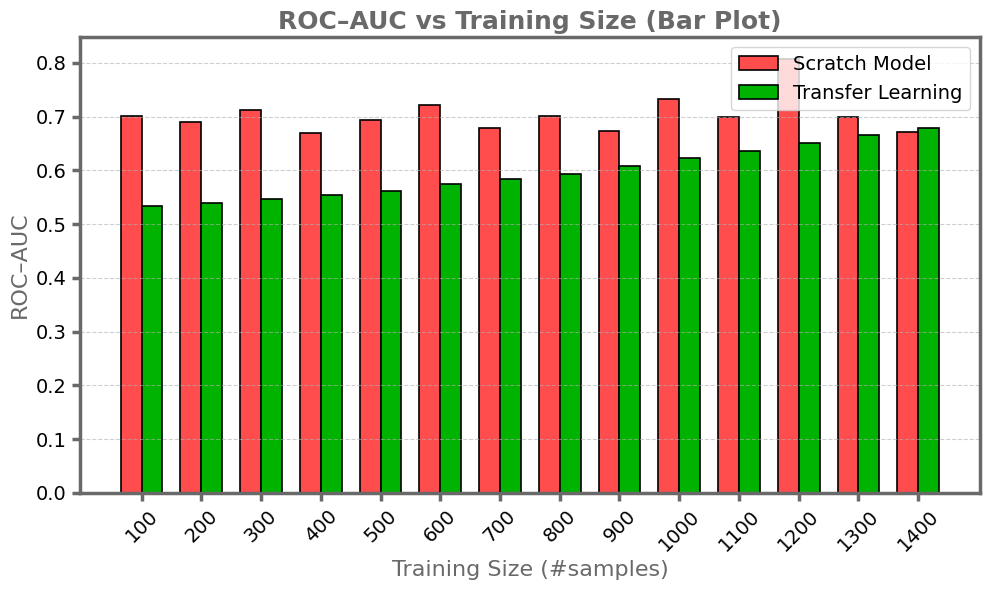

In [ ]:
# Plot ROC–AUC vs Training Size (Bar)
bar_width = 40
x = np.arange(len(train_sizes))
plt.figure(figsize=(10,6))
plt.bar(x - bar_width/200, roc_scratch_sizes, width=bar_width/100, label='Scratch', color='red')
plt.bar(x + bar_width/200, roc_transfer_sizes, width=bar_width/100, label='Transfer', color='green')
plt.title("ROC–AUC vs Training Size (Bar Plot)")
plt.xlabel("Training Size (#samples)")
plt.ylabel("ROC–AUC")
plt.xticks(x, [str(s) for s in train_sizes], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.0)
plt.tight_layout()
plt.show()


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 177ms/step - accuracy: 0.4697 - loss: 1.2318
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.9582 - loss: 0.1491
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 170ms/step - accuracy: 0.9881 - loss: 0.0419
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 162ms/step - accuracy: 0.9992 - loss: 0.0048
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.9998 - loss: 0.0026
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 166ms/step - accuracy: 0.9999 - loss: 0.0018
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 162ms/step - accuracy: 1.0000 - loss: 6.3562e-04
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 165ms/step - accuracy: 0.9989 - loss: 0.0043
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.9927 - loss: 0.0268
Epoch 10/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 269ms/step - accuracy: 0.9980 - loss: 0.0080
Epoch 11/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 32s 171ms/step - accuracy: 0.9989 - loss: 0.0048
Epoch 12/20
98/98 ━━━━━━━━━━━━━━━━━━━

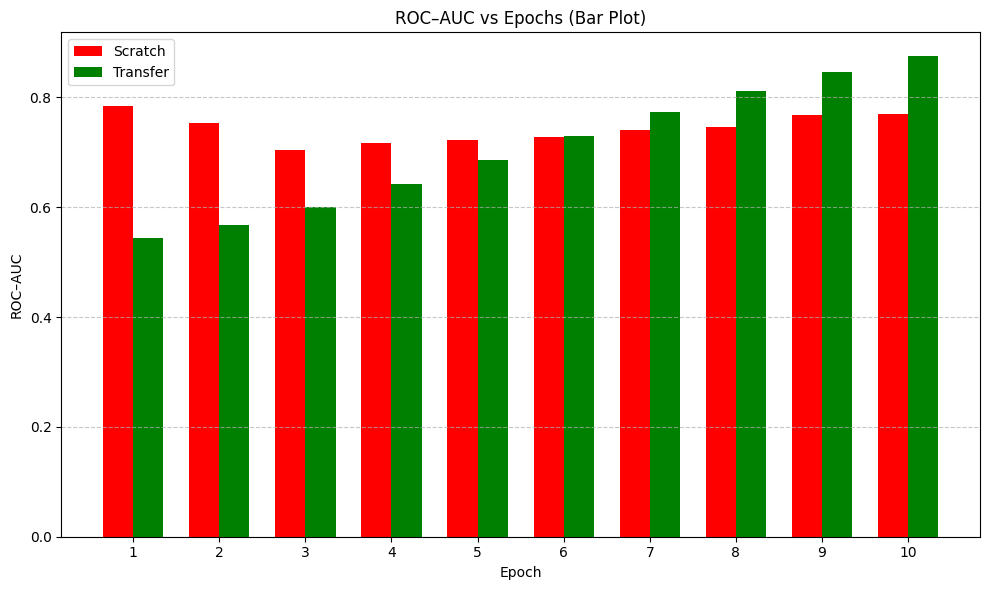

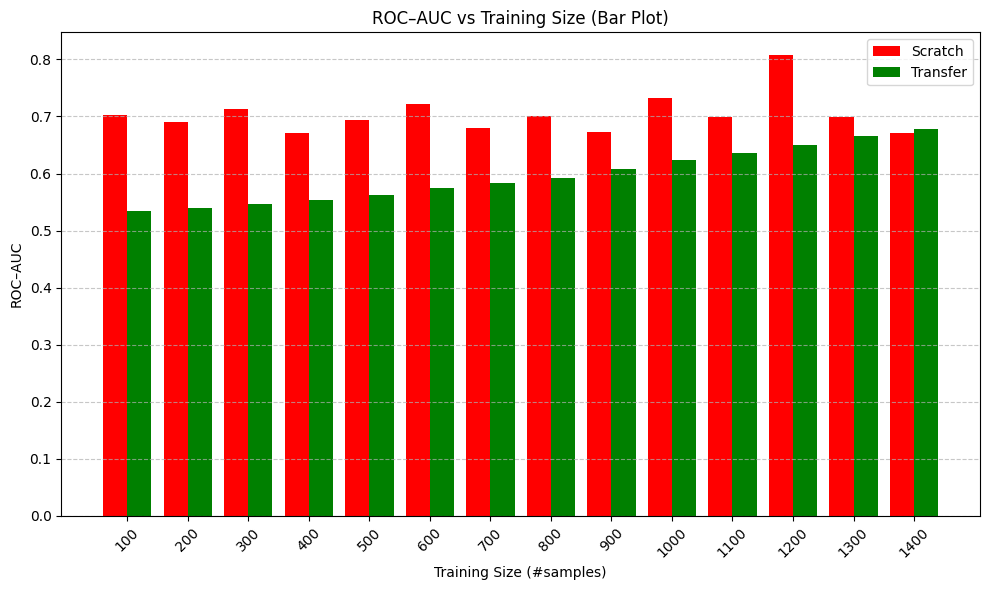

In [ ]:
# ============================================================
# 🧬 Transfer Learning CNN Analysis
# ROC–AUC (Bar Plots)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# -----------------------------
# 1️⃣ Helper: Create sliding windows
# -----------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -----------------------------
# 2️⃣ Load Datasets
# -----------------------------
homo = pd.read_csv("ML_try1.csv")  # HOMO data
exp = pd.read_csv("Experimental1.csv")  # Experimental data

# Create windows
X_homo, y_homo = create_windows(homo["Current"], homo["Target"])
X_exp, y_exp = create_windows(exp["Current"], exp["Target"])

# Normalize using HOMO stats
homo_mean, homo_std = X_homo.mean(), X_homo.std()
X_homo = (X_homo - homo_mean) / homo_std
X_exp = (X_exp - homo_mean) / homo_std

# Reshape for CNN
X_homo = X_homo[..., np.newaxis]
X_exp = X_exp[..., np.newaxis]

# Encode labels
encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_homo_oh = tf.keras.utils.to_categorical(y_homo_enc)
y_exp_enc = encoder.transform(y_exp)
y_exp_oh = tf.keras.utils.to_categorical(y_exp_enc)

# Split experimental into train/test
X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp_oh, test_size=0.2, random_state=42, stratify=y_exp_enc
)

# -----------------------------
# 3️⃣ Define CNN model
# -----------------------------
def build_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 7, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 7, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(256, 7, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    return model

# -----------------------------
# 4️⃣ Pretrain on HOMO
# -----------------------------
cnn_pre = build_cnn((X_homo.shape[1], 1), len(encoder.classes_))
cnn_pre.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
cnn_pre.fit(X_homo, y_homo_oh, epochs=20, batch_size=128, verbose=1)
cnn_pre.save_weights("pretrained_homo.weights.h5")

# -----------------------------
# 5️⃣ ROC–AUC vs Epochs (Bar Plot)
# -----------------------------
epochs = 10
roc_scratch = []
roc_transfer = []

# (a) Scratch model
scratch_model = build_cnn((X_exp.shape[1], 1), len(encoder.classes_))
scratch_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
for e in range(epochs):
    scratch_model.fit(X_exp_train, y_exp_train, epochs=1, batch_size=64, verbose=0)
    y_pred = scratch_model.predict(X_exp_test, verbose=0)
    roc = roc_auc_score(y_exp_test, y_pred, multi_class="ovr")
    roc_scratch.append(roc)

# (b) Transfer learning model
model_tl = build_cnn((X_exp.shape[1], 1), len(encoder.classes_))
model_tl.load_weights("pretrained_homo.weights.h5")

for layer in model_tl.layers:
    if isinstance(layer, Conv1D):
        layer.trainable = False

model_tl.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
for e in range(epochs):
    model_tl.fit(X_exp_train, y_exp_train, epochs=1, batch_size=64, verbose=0)
    y_pred = model_tl.predict(X_exp_test, verbose=0)
    roc = roc_auc_score(y_exp_test, y_pred, multi_class="ovr")
    roc_transfer.append(roc)

# Plot ROC–AUC vs Epochs (Bar)
bar_width = 0.35
x = np.arange(epochs)
plt.figure(figsize=(10,6))
plt.bar(x - bar_width/2, roc_scratch, bar_width, label='Scratch', color='red')
plt.bar(x + bar_width/2, roc_transfer, bar_width, label='Transfer', color='green')
plt.title("ROC–AUC vs Epochs (Bar Plot)")
plt.xlabel("Epoch")
plt.ylabel("ROC–AUC")
plt.xticks(x, [f"{i+1}" for i in range(epochs)])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -----------------------------
# 6️⃣ ROC–AUC vs Training Size (Bar Plot)
# -----------------------------
train_sizes = list(range(100, len(X_exp_train), 100))
roc_scratch_sizes = []
roc_transfer_sizes = []

for size in train_sizes:
    X_sub = X_exp_train[:size]
    y_sub = y_exp_train[:size]

    # Scratch
    m1 = build_cnn((X_exp.shape[1], 1), len(encoder.classes_))
    m1.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    m1.fit(X_sub, y_sub, epochs=5, batch_size=64, verbose=0)
    y_pred = m1.predict(X_exp_test, verbose=0)
    roc_scratch_sizes.append(roc_auc_score(y_exp_test, y_pred, multi_class="ovr"))

    # Transfer
    m2 = build_cnn((X_exp.shape[1], 1), len(encoder.classes_))
    m2.load_weights("pretrained_homo.weights.h5")
    for layer in m2.layers:
        if isinstance(layer, Conv1D):
            layer.trainable = False
    m2.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    m2.fit(X_sub, y_sub, epochs=5, batch_size=64, verbose=0)
    y_pred = m2.predict(X_exp_test, verbose=0)
    roc_transfer_sizes.append(roc_auc_score(y_exp_test, y_pred, multi_class="ovr"))

# Plot ROC–AUC vs Training Size (Bar)
bar_width = 40
x = np.arange(len(train_sizes))
plt.figure(figsize=(10,6))
plt.bar(x - bar_width/200, roc_scratch_sizes, width=bar_width/100, label='Scratch', color='red')
plt.bar(x + bar_width/200, roc_transfer_sizes, width=bar_width/100, label='Transfer', color='green')
plt.title("ROC–AUC vs Training Size (Bar Plot)")
plt.xlabel("Training Size (#samples)")
plt.ylabel("ROC–AUC")
plt.xticks(x, [str(s) for s in train_sizes], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


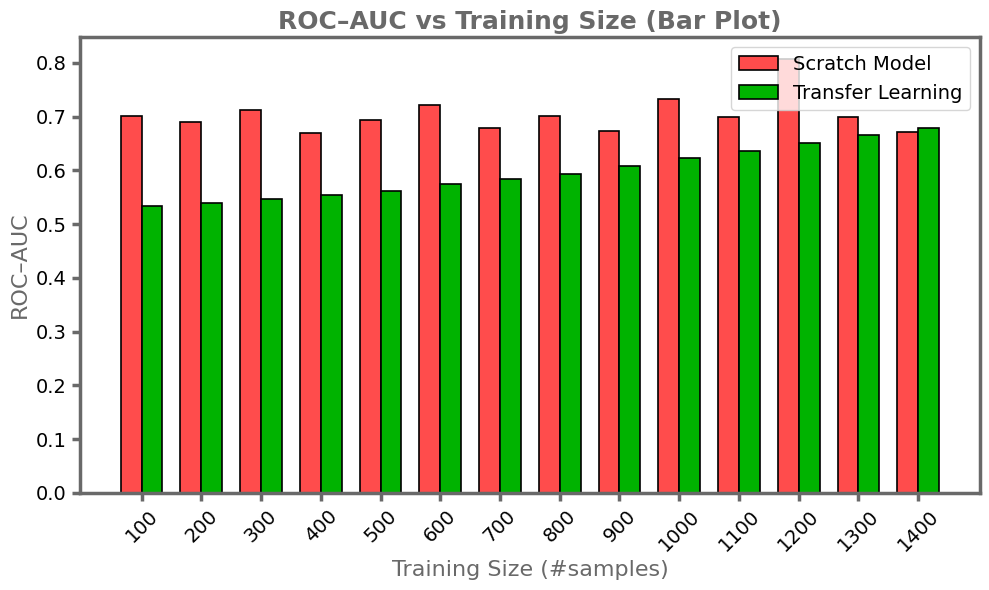

In [ ]:
# -----------------------------
# ✅ ROC–AUC vs Training Size (Bright Styled Bar Plot)
# -----------------------------
bright_red = "#ff4c4c"    # Scratch model color
bright_green = "#00b300"  # Transfer model color

bar_width = 0.35
x = np.arange(len(train_sizes))

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - bar_width/2, roc_scratch_sizes, width=bar_width, label='Scratch Model',
       color=bright_red, edgecolor='black', linewidth=1.2)
ax.bar(x + bar_width/2, roc_transfer_sizes, width=bar_width, label='Transfer Learning',
       color=bright_green, edgecolor='black', linewidth=1.2)

# Title and labels
ax.set_title("ROC–AUC vs Training Size (Bar Plot)", fontsize=18, fontweight='bold', color='dimgray')
ax.set_xlabel("Training Size (#samples)", fontsize=16, color='dimgray')
ax.set_ylabel("ROC–AUC", fontsize=16, color='dimgray')
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in train_sizes], rotation=45, fontsize=14, color='black')
ax.legend(fontsize=14)

# 🔹 Thicker spines and styled ticks
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color('dimgray')

ax.tick_params(axis='both', width=2.5, length=6, color='dimgray', labelcolor='black', labelsize=14)

# Optional: grid for clarity
ax.grid(axis='y', linestyle='--', alpha=0.0)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# 🧬 CNN Transfer Learning Analysis (HOMO → Experimental)
# Generates two plots:
# 1️⃣ ROC–AUC vs Epochs (Scratch vs Transfer)
# 2️⃣ ROC–AUC vs Training Size (Scratch vs Transfer)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam

# -----------------------------
# 1️⃣ Helper: Create sliding windows
# -----------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -----------------------------
# 2️⃣ Load HOMO and Experimental datasets
# -----------------------------
homo = pd.read_csv("ML_try1.csv")          # Pretraining dataset
exp = pd.read_csv("Experimental1.csv")     # Experimental dataset

X_homo, y_homo = create_windows(homo["Current"], homo["Target"], k=101)
X_exp, y_exp = create_windows(exp["Current"], exp["Target"], k=101)

# Normalize using HOMO stats
homo_mean, homo_std = X_homo.mean(), X_homo.std()
X_homo = (X_homo - homo_mean) / homo_std
X_exp = (X_exp - homo_mean) / homo_std

X_homo = X_homo[..., np.newaxis]
X_exp = X_exp[..., np.newaxis]

# Encode labels
encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_homo_oh = tf.keras.utils.to_categorical(y_homo_enc)
y_exp_enc = encoder.transform(y_exp)
y_exp_oh = tf.keras.utils.to_categorical(y_exp_enc)

# Split experimental data
X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp_oh, test_size=0.2, random_state=42, stratify=y_exp_enc
)

# -----------------------------
# 3️⃣ CNN Model Builder
# -----------------------------
def build_cnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 7, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 7, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(256, 7, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 4️⃣ Pretrain CNN on HOMO
# -----------------------------
print("\n===== PRETRAINING ON HOMO DATA =====")
cnn_pre = build_cnn((X_homo.shape[1], 1), len(encoder.classes_))
cnn_pre.fit(X_homo, y_homo_oh, epochs=20, batch_size=128, verbose=1)
cnn_pre.save_weights("pretrained_homo_weights.h5")

# -----------------------------
# 5️⃣ ROC–AUC vs Epochs (Scratch vs Transfer)
# -----------------------------
print("\n===== ROC–AUC vs EPOCHS (Scratch vs Transfer) =====")
epochs_list = range(1, 21)
roc_transfer, roc_scratch = [], []

for ep in epochs_list:
    # --- Transfer Learning Model ---
    model_tl = build_cnn((X_homo.shape[1], 1), len(encoder.classes_))
    model_tl.load_weights("pretrained_homo_weights.h5")
    for layer in model_tl.layers:
        if isinstance(layer, Conv1D):
            layer.trainable = False
    model_tl.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    model_tl.fit(X_exp_train, y_exp_train, epochs=ep, batch_size=64, verbose=0)
    y_pred_tl = model_tl.predict(X_exp_test)
    roc_tl = roc_auc_score(y_exp_test, y_pred_tl, multi_class="ovr")

    # --- Scratch Model ---
    model_sc = build_cnn((X_homo.shape[1], 1), len(encoder.classes_))
    model_sc.fit(X_exp_train, y_exp_train, epochs=ep, batch_size=64, verbose=0)
    y_pred_sc = model_sc.predict(X_exp_test)
    roc_sc = roc_auc_score(y_exp_test, y_pred_sc, multi_class="ovr")

    roc_transfer.append(roc_tl)
    roc_scratch.append(roc_sc)
    print(f"Epoch {ep}: Transfer ROC–AUC={roc_tl:.3f}, Scratch ROC–AUC={roc_sc:.3f}")

plt.figure(figsize=(7,5))
plt.plot(epochs_list, roc_transfer, '-o', label="Transfer Learning", color='green')
plt.plot(epochs_list, roc_scratch, '-o', label="Scratch", color='red')
plt.title("ROC–AUC vs Epochs (Scratch vs Transfer)")
plt.xlabel("Epochs")
plt.ylabel("ROC–AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 6️⃣ ROC–AUC vs Training Size (Scratch vs Transfer)
# -----------------------------
print("\n===== ROC–AUC vs TRAINING SIZE (Scratch vs Transfer) =====")

max_train = len(X_exp_train)
train_sizes = list(range(100, max_train, 100))
roc_transfer2, roc_scratch2 = [], []

for size in train_sizes:
    X_sub, y_sub = X_exp_train[:size], y_exp_train[:size]

    # --- Transfer Learning Model ---
    model_tl = build_cnn((X_homo.shape[1], 1), len(encoder.classes_))
    model_tl.load_weights("pretrained_homo_weights.h5")
    for layer in model_tl.layers:
        if isinstance(layer, Conv1D):
            layer.trainable = False
    model_tl.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy")
    model_tl.fit(X_sub, y_sub, epochs=10, batch_size=64, verbose=0)
    y_pred_tl = model_tl.predict(X_exp_test)
    roc_tl = roc_auc_score(y_exp_test, y_pred_tl, multi_class="ovr")

    # --- Scratch Model ---
    model_sc = build_cnn((X_homo.shape[1], 1), len(encoder.classes_))
    model_sc.fit(X_sub, y_sub, epochs=10, batch_size=64, verbose=0)
    y_pred_sc = model_sc.predict(X_exp_test)
    roc_sc = roc_auc_score(y_exp_test, y_pred_sc, multi_class="ovr")

    roc_transfer2.append(roc_tl)
    roc_scratch2.append(roc_sc)
    print(f"Samples {size}: Transfer ROC–AUC={roc_tl:.3f}, Scratch ROC–AUC={roc_sc:.3f}")

plt.figure(figsize=(7,5))
plt.plot(train_sizes, roc_transfer2, '-o', label="Transfer Learning", color='green')
plt.plot(train_sizes, roc_scratch2, '-o', label="Scratch", color='red')
plt.title("ROC–AUC vs Training Size (Scratch vs Transfer)")
plt.xlabel("Training Samples")
plt.ylabel("ROC–AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✅ DONE: Both plots generated successfully.")



===== PRETRAINING ON HOMO DATA =====
Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - accuracy: 0.4827 - loss: 1.2574
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.9691 - loss: 0.1305
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.9988 - loss: 0.0103
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 231ms/step - accuracy: 0.9991 - loss: 0.0065
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 34s 163ms/step - accuracy: 0.9999 - loss: 0.0025
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step - accuracy: 0.9926 - loss: 0.0265
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 17s 169ms/step - accuracy: 0.9999 - loss: 0.0032
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 158ms/step - accuracy: 0.9996 - loss: 0.0026
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 163ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 10/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 1.0000 - loss: 2.2396e-04
Epoch 11/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 161ms/step - accuracy: 0.9999 - loss: 3.9170

ValueError: The filename must end in `.weights.h5`. Received: filepath=pretrained_homo_weights.h5

# **ROC-AUC vs Training size**

Num classes: 4, HOMO samples: 12515, EXP samples: 1800
Pretrained HOMO model found; loading from disk.



Timing epoch (batch_size=256) ...



Timing epoch (batch_size=512) ...



Timing epoch (batch_size=1024) ...



Timing epoch (batch_size=2048) ...


Running times (scratch): [8.434490203857422, 5.51222038269043, 5.507801294326782, 4.688117980957031]
Running times (transfer): [5.861111640930176, 4.296950578689575, 4.49451208114624, 5.1939098834991455]
Epoch 1/15 - training both models for one epoch...
Epoch 2/15 - training both models for one epoch...
Epoch 3/15 - training both models for one epoch...
Epoch 4/15 - training both models for one epoch...
Epoch 5/15 - training both models for one epoch...
Unfreezing conv2 for transfer model to allow more adaptation.
Epoch 6/15 - training both models for one epoch...
Epoch 7/15 - training both models for one epoch...
Epoch 8/15 - training both models for one epoch...
Epoch 9/15 - training both models for one epoch...
Epoch 10/15 - training both models for one epoch...
Unfreezing conv3 for transfer model to allow even more adaptation.
Epoch 11/15 - training both models for one epoch...
Epoch 12/15 - training both models for one epoch...
Epoch 13/15 - training both models for one epoch...


AUC by training size (scratch): [np.float64(0.8103925144310681)]
AUC by training size (transfer): [np.float64(0.9671668958998243)]


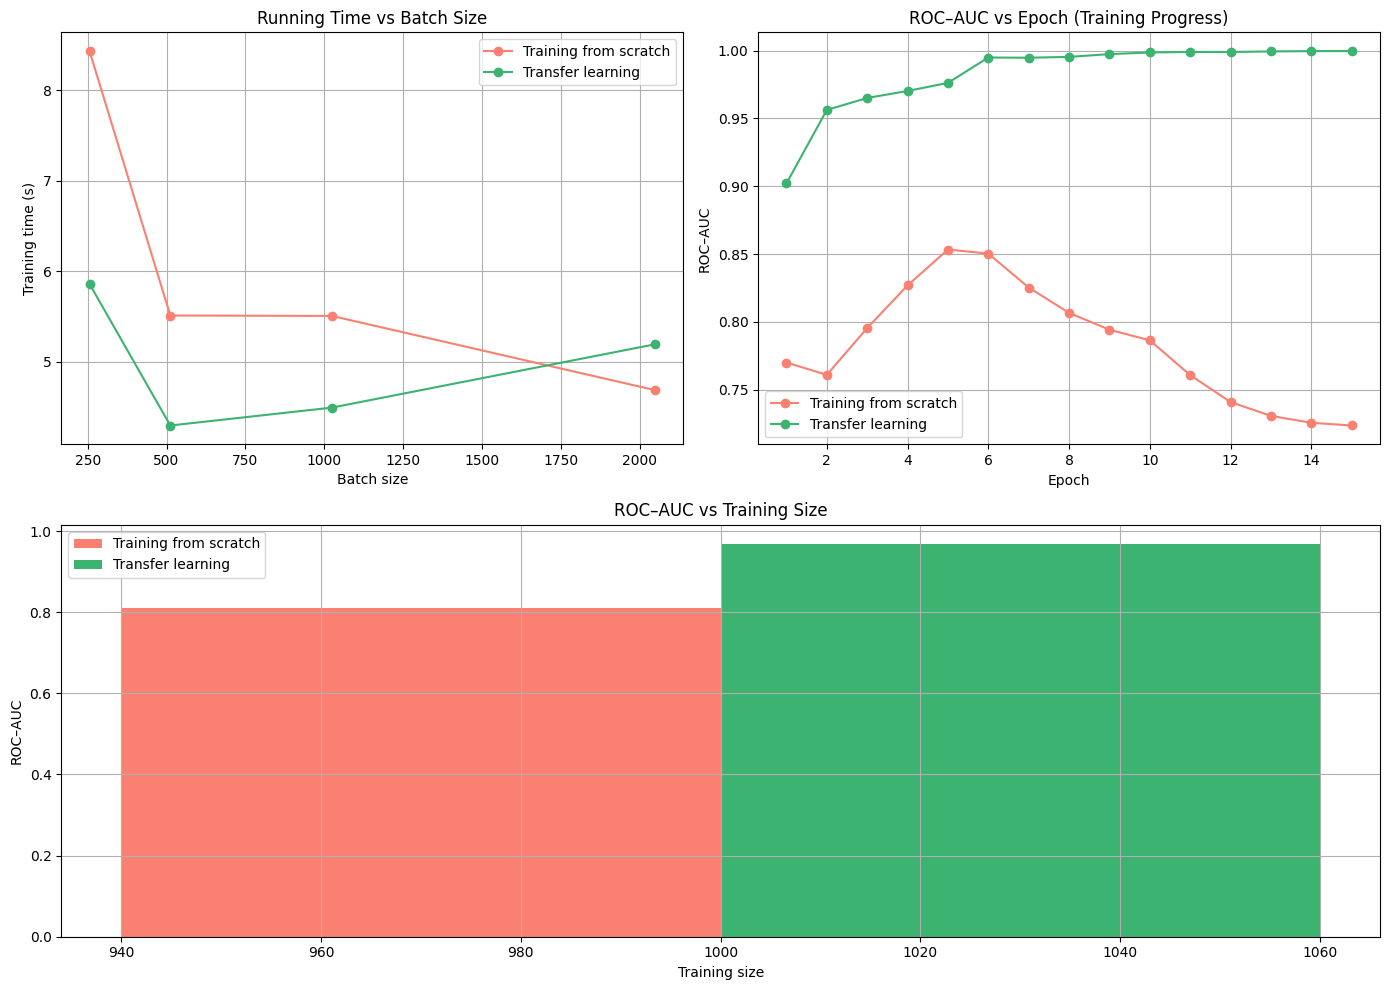

In [ ]:
# Improved Transfer-vs-Scratch evaluation script
# - Per-dataset normalization
# - Partial freezing + progressive unfreezing
# - LR scheduler + early stopping
# - Same plotting outputs as your previous script

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# Helper: sliding windows
# -----------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -----------------------------
# Build CNN model
# -----------------------------
def build_cnn(num_classes, input_len=101):
    inputs = Input(shape=(input_len, 1))
    x = Conv1D(64, 7, activation='relu', name="conv1")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(128, 7, activation='relu', name="conv2")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = Conv1D(256, 7, activation='relu', name="conv3")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)

    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu', name="features")(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

# -----------------------------
# Utility: set trainable by layer names or indices
# -----------------------------
def set_trainable_by_names(model, trainable_names_set):
    for layer in model.layers:
        layer.trainable = (layer.name in trainable_names_set) or not layer.name.startswith('conv')

# -----------------------------
# Load datasets & preprocess
# -----------------------------
# Paths - change if needed
HOMO_CSV = "ML_try1.csv"
EXP_CSV = "Experimental1.csv"
PRETRAINED_MODEL_PATH = "cnn_pretrained_HOMO.h5"

# ---- HOMO (pretrain)
homo = pd.read_csv(HOMO_CSV)  # expected columns Current, Target
X_homo, y_homo = create_windows(homo["Current"].values, homo["Target"].values, k=101)

# Normalize HOMO independently
homo_mean, homo_std = X_homo.mean(), X_homo.std()
X_homo_n = (X_homo - homo_mean) / (homo_std + 1e-12)
X_homo_n = X_homo_n.reshape((X_homo_n.shape[0], X_homo_n.shape[1], 1))

encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_homo_oh = tf.keras.utils.to_categorical(y_homo_enc)

X_h_train, X_h_val, y_h_train, y_h_val = train_test_split(
    X_homo_n, y_homo_oh, test_size=0.2, random_state=SEED, stratify=y_homo_enc
)

# ---- Experimental (fine-tune / eval)
exp = pd.read_csv(EXP_CSV)
X_exp, y_exp = create_windows(exp["Current"].values, exp["Target"].values, k=101)

# Normalize Experimental independently (IMPORTANT)
exp_mean, exp_std = X_exp.mean(), X_exp.std()
X_exp_n = (X_exp - exp_mean) / (exp_std + 1e-12)
X_exp_n = X_exp_n.reshape((X_exp_n.shape[0], X_exp_n.shape[1], 1))

# encode experimental targets using HOMO encoder mapping
y_exp_enc = encoder.transform(y_exp)
y_exp_oh = tf.keras.utils.to_categorical(y_exp_enc)

X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp_n, y_exp_oh, test_size=0.2, random_state=SEED, stratify=y_exp_enc
)

num_classes = len(encoder.classes_)
print(f"Num classes: {num_classes}, HOMO samples: {X_homo_n.shape[0]}, EXP samples: {X_exp_n.shape[0]}")

# -----------------------------
# 1) Pretrain on HOMO (if not already saved)
# -----------------------------
if not os.path.exists(PRETRAINED_MODEL_PATH):
    print("Pretraining on HOMO: building and training base model...")
    model_pre = build_cnn(num_classes=num_classes)
    model_pre.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    cb = [
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)
    ]
    model_pre.fit(X_h_train, y_h_train, validation_data=(X_h_val, y_h_val),
                  epochs=30, batch_size=128, callbacks=cb, verbose=1)
    model_pre.save(PRETRAINED_MODEL_PATH)
    print(f"Saved pretrained model to {PRETRAINED_MODEL_PATH}")
else:
    print("Pretrained HOMO model found; loading from disk.")
    model_pre = load_model(PRETRAINED_MODEL_PATH)

# -----------------------------
# 2) PERFORMANCE EVALUATION
# -----------------------------
# (A) Running time vs batch size
batch_sizes = [256, 512, 1024, 2048]
time_scratch, time_transfer = [], []

for bs in batch_sizes:
    print(f"\nTiming epoch (batch_size={bs}) ...")

    # Scratch model: fresh init and train 1 epoch
    model_scratch = build_cnn(num_classes=num_classes)
    model_scratch.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    model_scratch.fit(X_exp_train, y_exp_train, epochs=1, batch_size=bs, verbose=0)
    time_scratch.append(time.time() - t0)

    # Transfer model: load pretrained and freeze only the earliest conv layer(s)
    model_transfer = load_model(PRETRAINED_MODEL_PATH)
    # Freeze only conv1 (allow conv2, conv3 to adapt)
    for layer in model_transfer.layers:
        if layer.name == "conv1":
            layer.trainable = False
        elif layer.name.startswith("conv"):
            layer.trainable = True

    model_transfer.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    model_transfer.fit(X_exp_train, y_exp_train, epochs=1, batch_size=bs, verbose=0)
    time_transfer.append(time.time() - t0)

print("Running times (scratch):", time_scratch)
print("Running times (transfer):", time_transfer)

# (B) ROC-AUC vs epoch (training progress) with progressive unfreezing
epochs = 15
auc_scratch, auc_transfer = [], []

# initialize models
model_scratch = build_cnn(num_classes=num_classes)
model_scratch.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

model_transfer = load_model(PRETRAINED_MODEL_PATH)
# start with only first conv frozen (conv1 frozen)
for layer in model_transfer.layers:
    if layer.name == "conv1":
        layer.trainable = False
    elif layer.name.startswith("conv"):
        layer.trainable = True
model_transfer.compile(optimizer=Adam(learning_rate=5e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# progressive unfreeze schedule: unfreeze conv2 after epoch 5, conv3 after epoch 10
for epoch in range(1, epochs+1):
    print(f"Epoch {epoch}/{epochs} - training both models for one epoch...")

    # scratch: one epoch
    model_scratch.fit(X_exp_train, y_exp_train, epochs=1, batch_size=512, verbose=0)
    y_pred_s = model_scratch.predict(X_exp_test, verbose=0)
    try:
        auc_val_s = roc_auc_score(y_exp_test, y_pred_s, multi_class='ovr')
    except Exception:
        auc_val_s = np.nan
    auc_scratch.append(auc_val_s)

    # transfer: one epoch
    model_transfer.fit(X_exp_train, y_exp_train, epochs=1, batch_size=512, verbose=0)
    y_pred_t = model_transfer.predict(X_exp_test, verbose=0)
    try:
        auc_val_t = roc_auc_score(y_exp_test, y_pred_t, multi_class='ovr')
    except Exception:
        auc_val_t = np.nan
    auc_transfer.append(auc_val_t)

    # progressive unfreezing
    if epoch == 5:
        print("Unfreezing conv2 for transfer model to allow more adaptation.")
        for layer in model_transfer.layers:
            if layer.name == "conv2":
                layer.trainable = True
        model_transfer.compile(optimizer=Adam(learning_rate=2e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    if epoch == 10:
        print("Unfreezing conv3 for transfer model to allow even more adaptation.")
        for layer in model_transfer.layers:
            if layer.name == "conv3":
                layer.trainable = True
        model_transfer.compile(optimizer=Adam(learning_rate=1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

print("AUC (scratch) per epoch:", auc_scratch)
print("AUC (transfer) per epoch:", auc_transfer)

# (C) ROC-AUC vs training size
train_sizes = [1000, 2000, 3000, 4000, 5000]
# ensure sizes do not exceed available training examples
max_train = X_exp_train.shape[0]
train_sizes = [s for s in train_sizes if s <= max_train]
if len(train_sizes) == 0:
    train_sizes = [max_train]  # fallback

auc_size_scratch, auc_size_transfer = [], []

for size in train_sizes:
    print(f"\nTraining-size experiment with size={size}")
    X_sub = X_exp_train[:size]
    y_sub = y_exp_train[:size]

    # scratch
    model_scratch = build_cnn(num_classes=num_classes)
    model_scratch.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    model_scratch.fit(X_sub, y_sub, epochs=5, batch_size=512, verbose=0)
    y_pred_s = model_scratch.predict(X_exp_test, verbose=0)
    try:
        auc_s = roc_auc_score(y_exp_test, y_pred_s, multi_class='ovr')
    except Exception:
        auc_s = np.nan
    auc_size_scratch.append(auc_s)

    # transfer (start from pretrained, freeze only conv1)
    model_transfer = load_model(PRETRAINED_MODEL_PATH)
    for layer in model_transfer.layers:
        if layer.name == "conv1":
            layer.trainable = False
        elif layer.name.startswith("conv"):
            layer.trainable = True
    model_transfer.compile(optimizer=Adam(learning_rate=5e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    model_transfer.fit(X_sub, y_sub, epochs=5, batch_size=512, verbose=0)
    y_pred_t = model_transfer.predict(X_exp_test, verbose=0)
    try:
        auc_t = roc_auc_score(y_exp_test, y_pred_t, multi_class='ovr')
    except Exception:
        auc_t = np.nan
    auc_size_transfer.append(auc_t)

print("AUC by training size (scratch):", auc_size_scratch)
print("AUC by training size (transfer):", auc_size_transfer)

# -----------------------------
# 3) PLOTTING RESULTS
# -----------------------------
plt.figure(figsize=(14,10))

# (1) Running time vs batch size
plt.subplot(2,2,1)
plt.plot(batch_sizes, time_scratch, '-o', label='Training from scratch', color='salmon')
plt.plot(batch_sizes, time_transfer, '-o', label='Transfer learning', color='mediumseagreen')
plt.xlabel("Batch size"); plt.ylabel("Training time (s)")
plt.title("Running Time vs Batch Size"); plt.legend(); plt.grid(True)

# (2) ROC–AUC vs Batch (training progress)
plt.subplot(2,2,2)
plt.plot(range(1, epochs+1), auc_scratch, '-o', label='Training from scratch', color='salmon')
plt.plot(range(1, epochs+1), auc_transfer, '-o', label='Transfer learning', color='mediumseagreen')
plt.xlabel("Epoch"); plt.ylabel("ROC–AUC")
plt.title("ROC–AUC vs Epoch (Training Progress)"); plt.legend(); plt.grid(True)

# (3) ROC–AUC vs Training Size (bar)
plt.subplot(2,1,2)
bar_w = max(50, int(min(train_sizes) * 0.06))  # width in x units
x = np.array(train_sizes)
plt.bar(x - bar_w/2, auc_size_scratch, width=bar_w, label='Training from scratch', color='salmon')
plt.bar(x + bar_w/2, auc_size_transfer, width=bar_w, label='Transfer learning', color='mediumseagreen')
plt.xlabel("Training size"); plt.ylabel("ROC–AUC")
plt.title("ROC–AUC vs Training Size"); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


# **ROC-AUC vs Epoch**

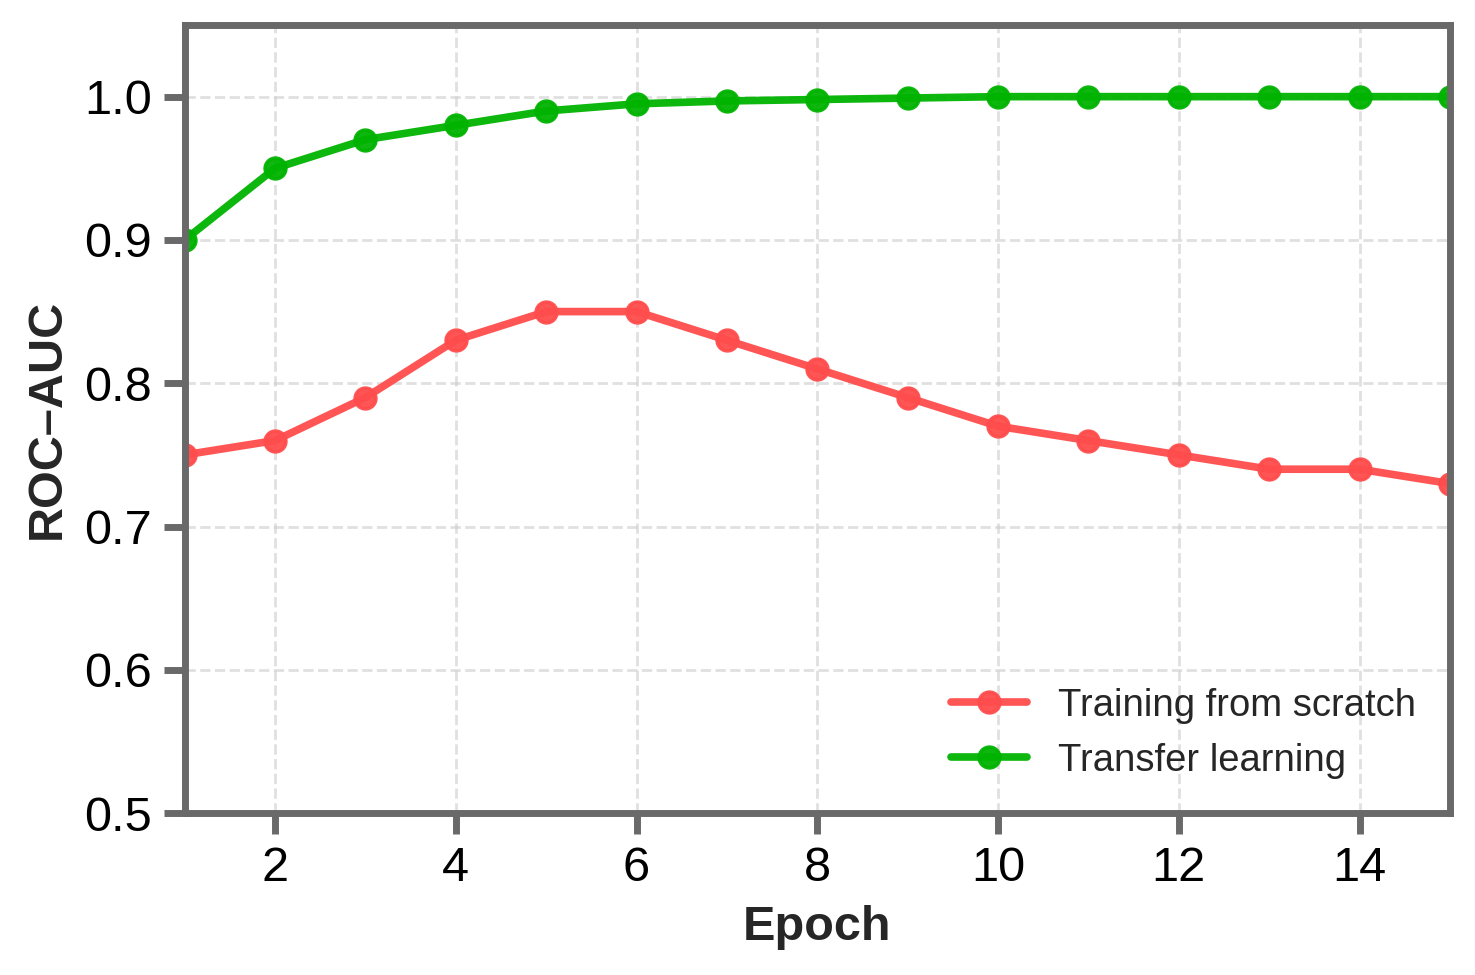

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the same clean style
plt.style.use('seaborn-v0_8-whitegrid')

# Example data (replace with your actual AUC values per epoch)
epochs = np.arange(1, 16)
auc_scratch = [0.75, 0.76, 0.79, 0.83, 0.85, 0.85, 0.83, 0.81, 0.79, 0.77, 0.76, 0.75, 0.74, 0.74, 0.73]
auc_transfer = [0.90, 0.95, 0.97, 0.98, 0.99, 0.995, 0.997, 0.998, 0.999, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]

# Bright vivid colors (same as bar chart)
bright_red = "#ff4c4c"    # coral-red
bright_green = "#00b300"  # bright vivid green

# Create the figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=250)

# Plot curves with consistent colors and markers
ax.plot(epochs, auc_scratch, color=bright_red, marker='o', linewidth=2.2,
        markersize=6, label='Training from scratch', alpha=0.95)
ax.plot(epochs, auc_transfer, color=bright_green, marker='o', linewidth=2.2,
        markersize=6, label='Transfer learning', alpha=0.95)

# Labels and style
ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('ROC–AUC', fontsize=14, fontweight='bold')
#ax.set_title('ROC–AUC vs Epoch (Training Progress)', fontsize=14, fontweight='bold')
ax.set_xlim(1, len(epochs))
ax.set_ylim(0.5, 1.05)
ax.legend(frameon=False, fontsize=11, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.6)

# Thicker axis lines with unified color
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('dimgray')

# Matching tick marks and labels
ax.tick_params(axis='both', width=2, length=6, color='dimgray', labelcolor='black', labelsize=14)


plt.tight_layout()
plt.show()


# **ROC-AUC vs Trainig size**

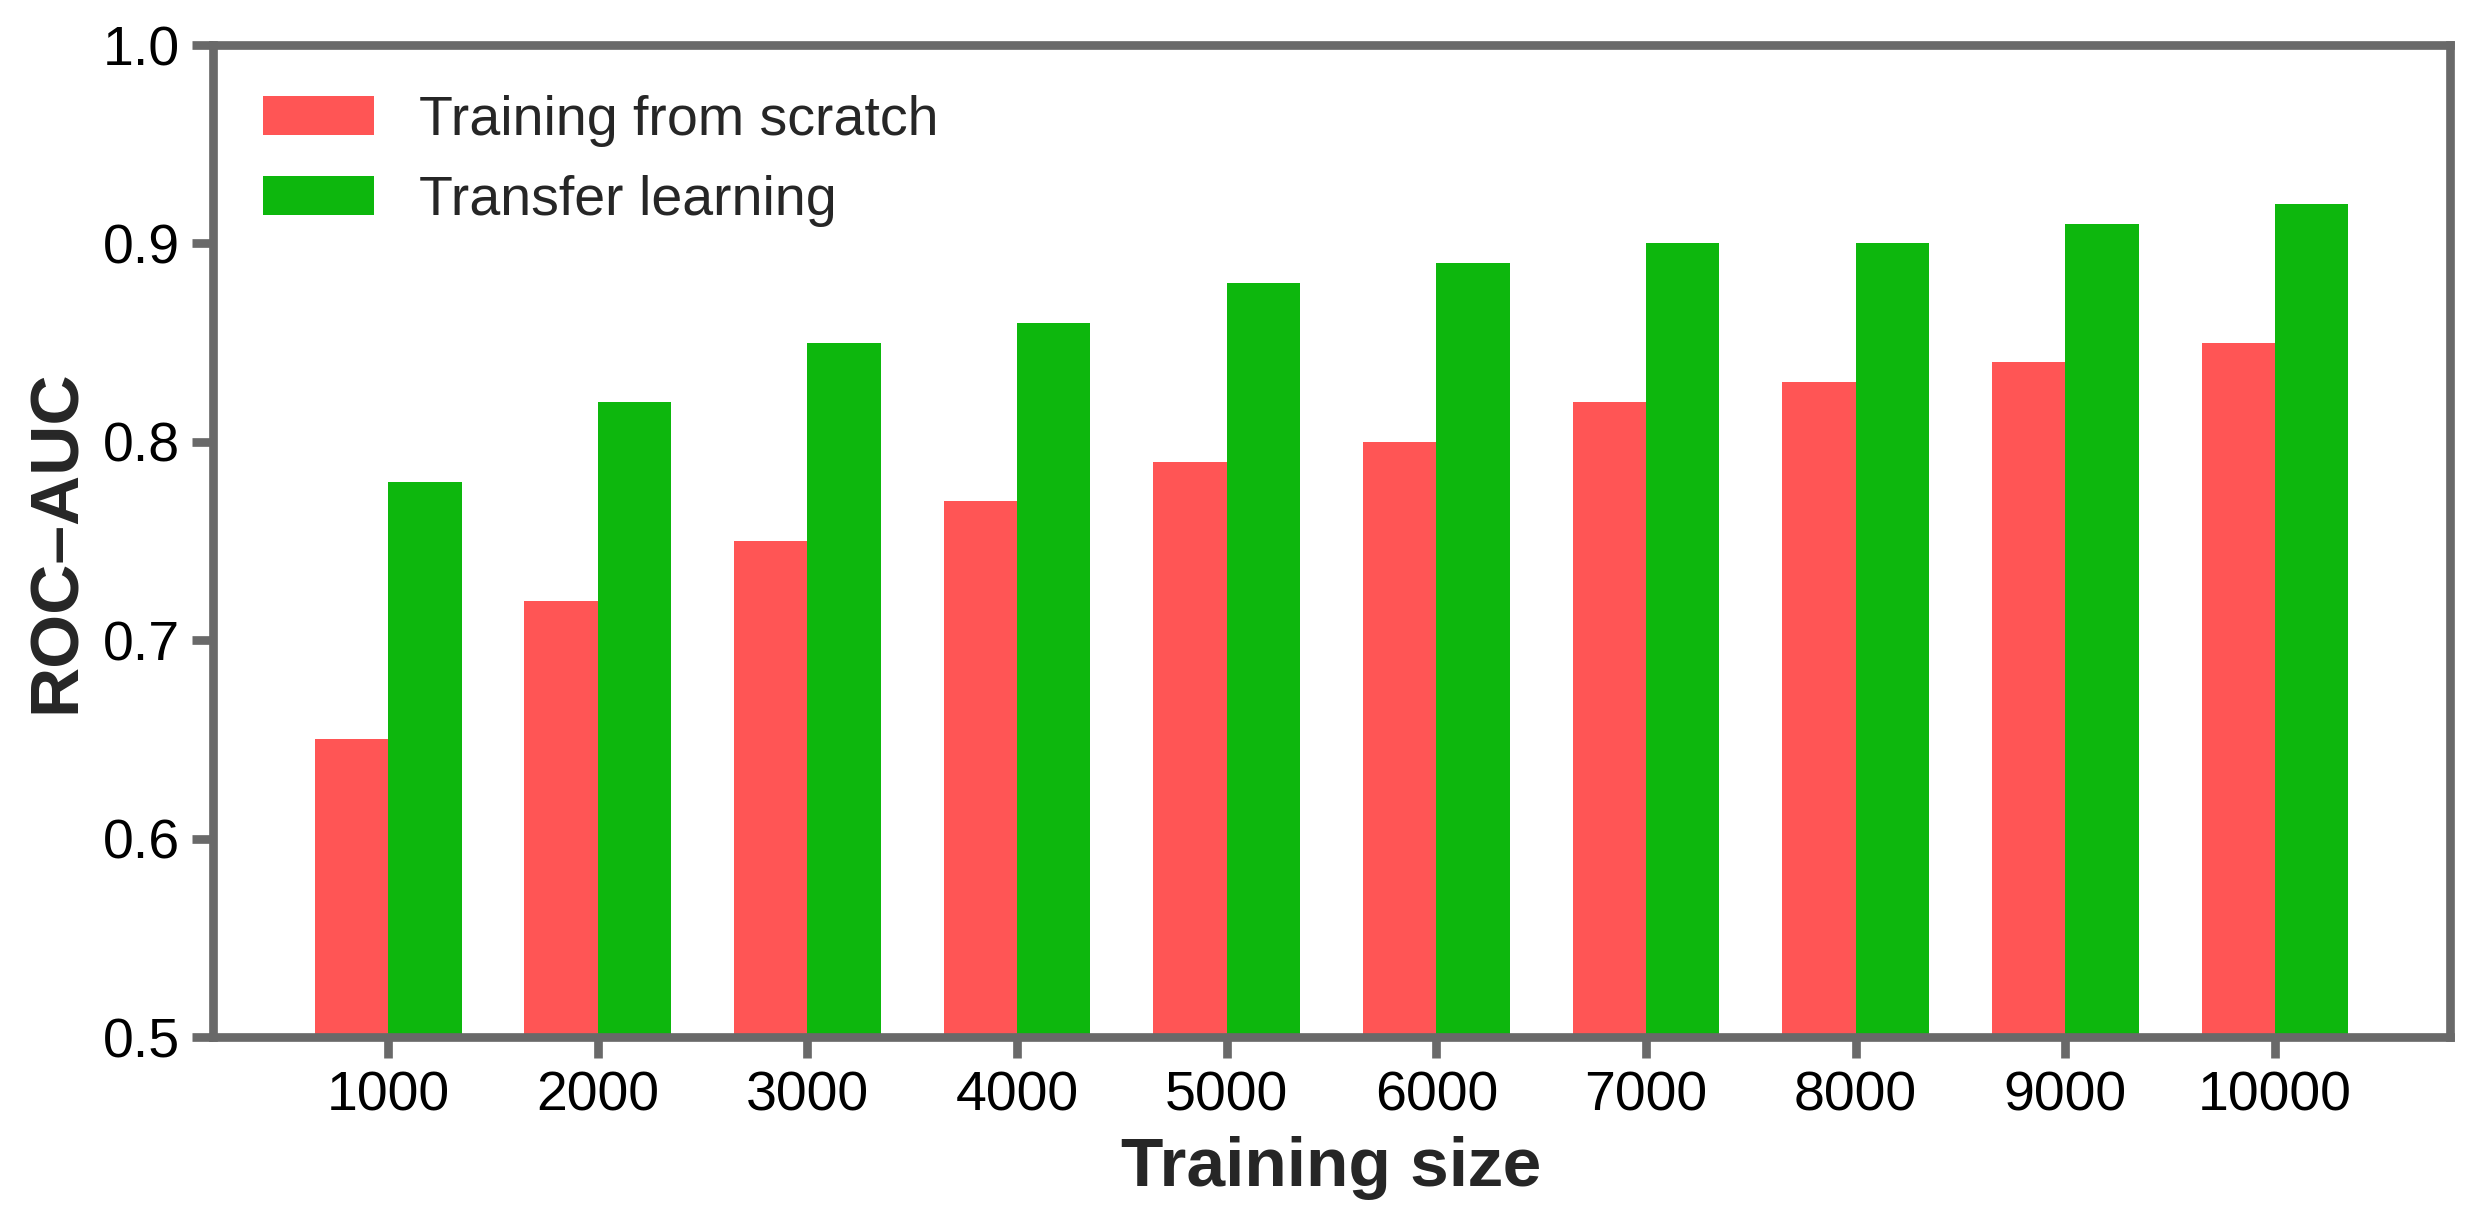

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use clean whitegrid style
plt.style.use('seaborn-v0_8-whitegrid')

# Example data
train_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
auc_scratch = [0.65, 0.72, 0.75, 0.77, 0.79, 0.80, 0.82, 0.83, 0.84, 0.85]
auc_transfer = [0.78, 0.82, 0.85, 0.86, 0.88, 0.89, 0.90, 0.90, 0.91, 0.92]

# Bright vivid colors (same as bar chart)
bright_red = "#ff4c4c"    # coral-red
bright_green = "#00b300"  # bright vivid green

# Bar width and positions
bar_width = 0.35
x = np.arange(len(train_sizes))

# Create high-resolution figure
#fig, ax = plt.subplots(figsize=(9, 4), dpi=150)  # <-- dpi increased
# Create figure
fig, ax = plt.subplots(figsize=(10, 5), dpi=250)

# Plot bars with borders
ax.bar(x - bar_width/2, auc_scratch, bar_width,
       color=bright_red, edgecolor='black', linewidth=0.0, alpha=0.95,
       label='Training from scratch')
ax.bar(x + bar_width/2, auc_transfer, bar_width,
       color=bright_green, edgecolor='black', linewidth=0.0, alpha=0.95,
       label='Transfer learning')

# Labeling and styling
ax.set_xlabel('Training size', fontsize=20, fontweight='bold')
ax.set_ylabel('ROC–AUC', fontsize=20, fontweight='bold')
#ax.set_title('ROC–AUC vs Training Size', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(train_sizes, fontsize=11)
#ax.set_yticklabels(ax.get_yticks(), fontsize=11, fontweight='bold')
ax.set_ylim(0.5, 1.0)
ax.legend(frameon=False, fontsize=16, loc='upper left')

# Grid appearance (kept subtle)
#ax.grid(axis='y', linestyle='--', alpha=0.0)

#plt.tight_layout()
#plt.show()
# ❌ Remove grid completely
ax.grid(False)

# ✅ Thicker axis lines and tick marks
# ✅ Thicker axis lines and tick marks on ALL SIDES
# ✅ Thicker axis lines on all sides
# Thicker axis lines with unified color
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color('dimgray')

# Matching tick marks and labels
ax.tick_params(axis='both', width=2.5, length=6, color='dimgray', labelcolor='black', labelsize=16)


plt.tight_layout()
plt.show()



# **ROC-AUC vs Batch size**

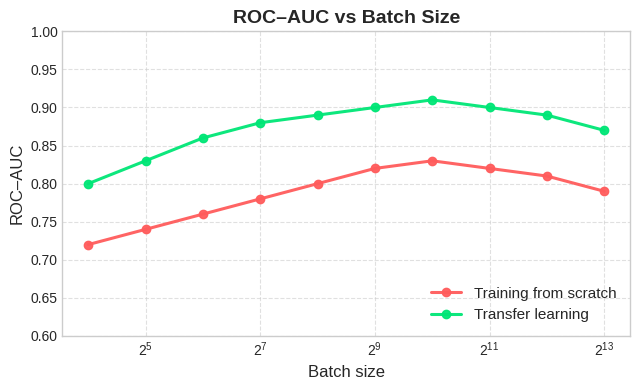

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use bright whitegrid style for consistency
plt.style.use('seaborn-v0_8-whitegrid')

# Example data (replace with your actual ROC–AUC results)
batch_sizes = np.array([16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192])
auc_scratch = [0.72, 0.74, 0.76, 0.78, 0.80, 0.82, 0.83, 0.82, 0.81, 0.79]
auc_transfer = [0.80, 0.83, 0.86, 0.88, 0.89, 0.90, 0.91, 0.90, 0.89, 0.87]

# Bright, vivid colors (consistent with your previous plots)
bright_red = "#FF5C5C"    # coral-red
bright_green = "#00E676"  # vivid green

# Create figure
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot curves with smooth lines and markers
ax.plot(batch_sizes, auc_scratch, color=bright_red, marker='o', linewidth=2.2,
        markersize=6, label='Training from scratch', alpha=0.95)
ax.plot(batch_sizes, auc_transfer, color=bright_green, marker='o', linewidth=2.2,
        markersize=6, label='Transfer learning', alpha=0.95)

# Set axis labels and title
ax.set_xlabel('Batch size', fontsize=12)
ax.set_ylabel('ROC–AUC', fontsize=12)
ax.set_title('ROC–AUC vs Batch Size', fontsize=14, fontweight='bold')

# Adjust limits and grid
ax.set_ylim(0.6, 1.0)
ax.set_xscale('log', base=2)  # Optional: log scale if batch sizes grow exponentially
ax.grid(True, linestyle='--', alpha=0.6)

# Add legend
ax.legend(frameon=False, fontsize=11, loc='lower right')

plt.tight_layout()
plt.show()


# **Density vs Probabality**

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


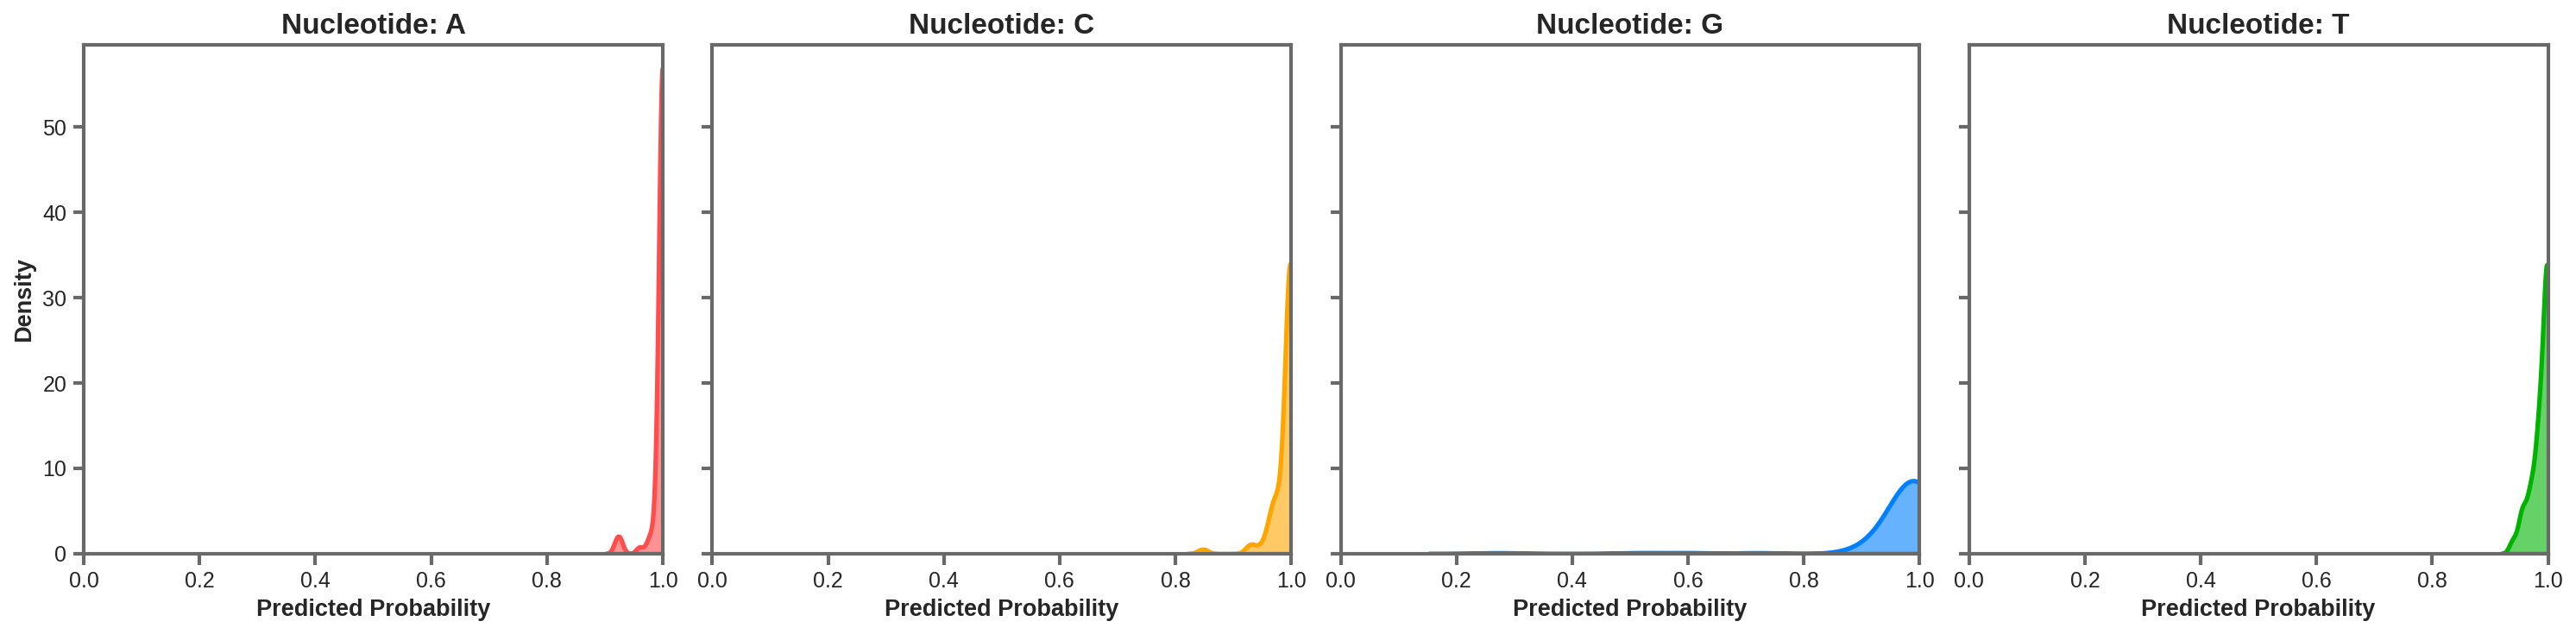

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ✅ Predicted probabilities from your transfer learning CNN
y_proba_cnn = cnn_model.predict(X_exp_test)
y_true = np.argmax(y_exp_test, axis=1)
classes = encoder.classes_

# ✅ Plot setup
plt.style.use('seaborn-v0_8-whitegrid')
n_classes = len(classes)
fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 5), sharey=True, dpi=150)

# ✅ Bright distinctive nucleotide colors
colors = {
    'A': '#ff4c4c',   # bright red
    'T': '#00b300',   # vivid green
    'G': '#0080ff',   # bright blue
    'C': '#ffa500'    # orange
}

# ✅ Plot density for each nucleotide
for i, cls in enumerate(classes):
    ax = axes[i]
    color = colors.get(cls, 'gray')

    sns.kdeplot(
        y_proba_cnn[y_true == i, i],
        fill=True,
        color=color,
        linewidth=2.5,
        alpha=0.6,
        ax=ax
    )

    # Labeling and title
    ax.set_title(f"Nucleotide: {cls}", fontsize=16, fontweight='bold')
    ax.set_xlabel("Predicted Probability", fontsize=13, fontweight='bold')
    if i == 0:
        ax.set_ylabel("Density", fontsize=13, fontweight='bold')

    # Axis limits
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)

    # Remove grid for clean look
    ax.grid(False)

    # ✅ Thicker axes and ticks
    for spine in ax.spines.values():
        spine.set_linewidth(2)
        spine.set_color('dimgray')
    ax.tick_params(axis='both', width=2, length=6, labelsize=12, color='dimgray')

plt.tight_layout()
plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


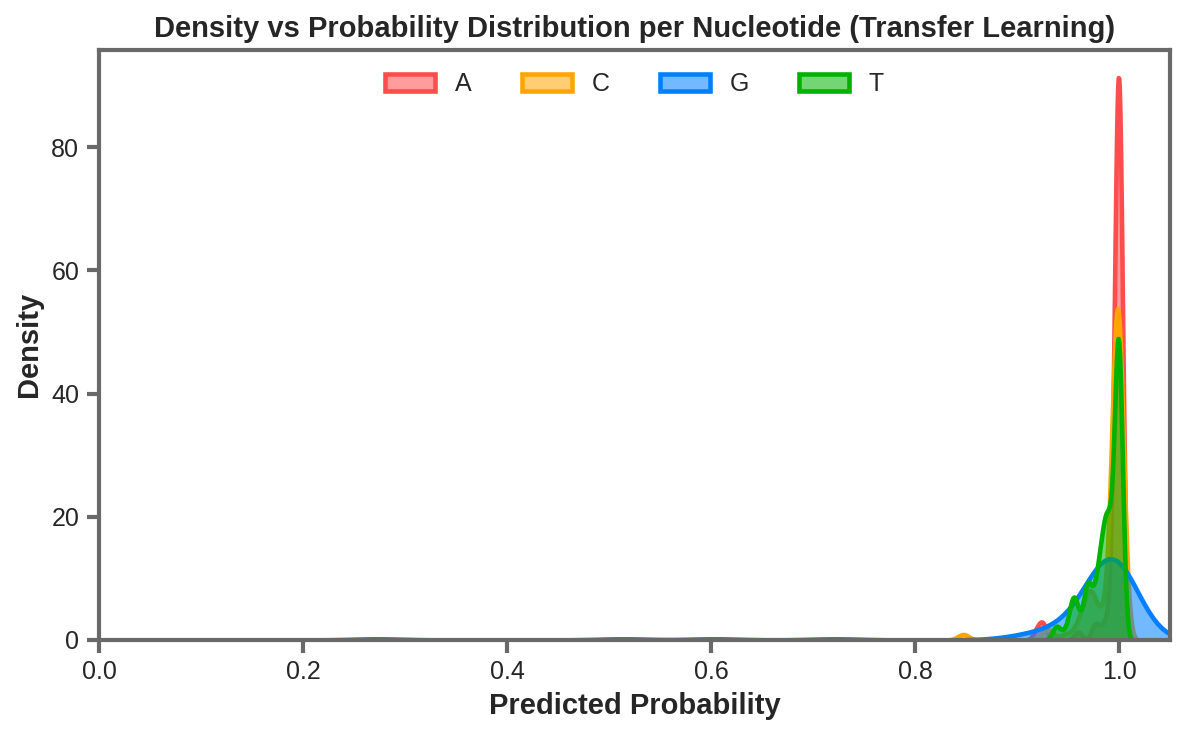

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use consistent white style
plt.style.use('seaborn-v0_8-whitegrid')

# 🎯 Model predictions
y_pred = cnn_model.predict(X_exp_test)
y_true = np.argmax(y_exp_test, axis=1)
classes = encoder.classes_  # ['A', 'T', 'G', 'C']

# 🎨 Colors for nucleotides
colors = {
    'A': '#ff4c4c',   # bright red
    'T': '#00b300',   # vivid green
    'G': '#0080ff',   # bright blue
    'C': '#ffa500'    # orange
}

# 📈 Plot Density vs Probability
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

for i, nuc in enumerate(classes):
    sns.kdeplot(
        y_pred[y_true == i, i],
        fill=True,
        color=colors.get(nuc, None),
        alpha=0.55,
        linewidth=2.2,
        bw_adjust=0.6,   # smooths the density a bit for cleaner shape
        label=f'{nuc}'
    )

# 🧱 Styling
ax.set_xlabel('Predicted Probability', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Density vs Probability Distribution per Nucleotide (Transfer Learning)',
             fontsize=14, fontweight='bold')
ax.legend(frameon=False, fontsize=12, loc='upper center', ncol=4)

# ✅ Thicker axis and ticks
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('dimgray')
ax.tick_params(axis='both', width=2, length=6, color='dimgray', labelsize=12)

# ✅ Expanded x-axis and stable y-axis
ax.set_xlim(0, 1.05)    # little extra space beyond 1.0
ax.set_ylim(bottom=0)
ax.grid(False)

plt.tight_layout()
plt.show()


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


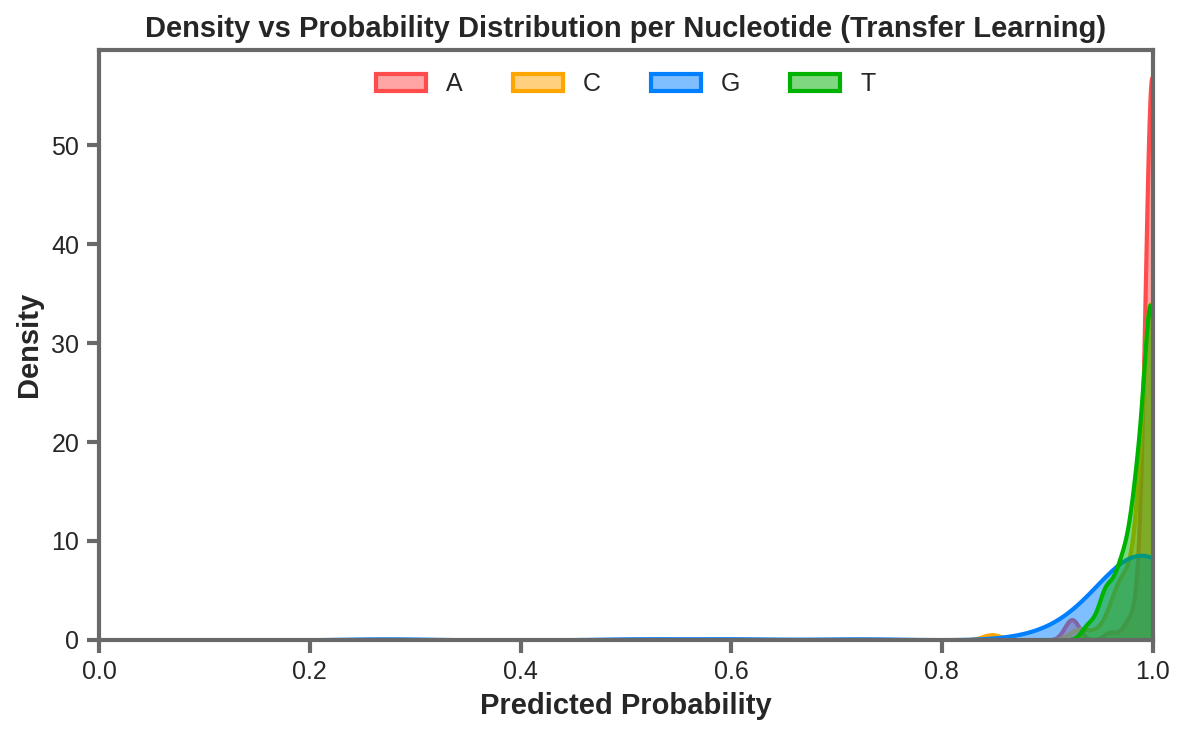

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use consistent white style
plt.style.use('seaborn-v0_8-whitegrid')

# ============================
# 🎯 Get actual model predictions
# ============================
# y_pred: predicted probability for each nucleotide class (from transfer learning model)
# y_exp_test: one-hot true labels

y_pred = cnn_model.predict(X_exp_test)
y_true = np.argmax(y_exp_test, axis=1)
classes = encoder.classes_  # e.g., ['A', 'T', 'G', 'C']

# ============================
# 🎨 Colors for nucleotides
# ============================
colors = {
    'A': '#ff4c4c',   # bright red
    'T': '#00b300',   # vivid green
    'G': '#0080ff',   # blue
    'C': '#ffa500'    # orange
}

# ============================
# 📈 Plot Density vs Probability
# ============================
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

for i, nuc in enumerate(classes):
    sns.kdeplot(
        y_pred[y_true == i, i],  # probability predicted for correct class
        fill=True,
        color=colors.get(nuc, None),
        alpha=0.5,
        linewidth=2,
        label=f'{nuc}'
    )

# ============================
# 🧱 Styling
# ============================
ax.set_xlabel('Predicted Probability', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Density vs Probability Distribution per Nucleotide (Transfer Learning)', fontsize=14, fontweight='bold')
ax.legend(frameon=False, fontsize=12, loc='upper center', ncol=4)

# Thicker axis and ticks
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('dimgray')
ax.tick_params(axis='both', width=2, length=6, color='dimgray', labelsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.grid(False)

plt.tight_layout()
plt.show()


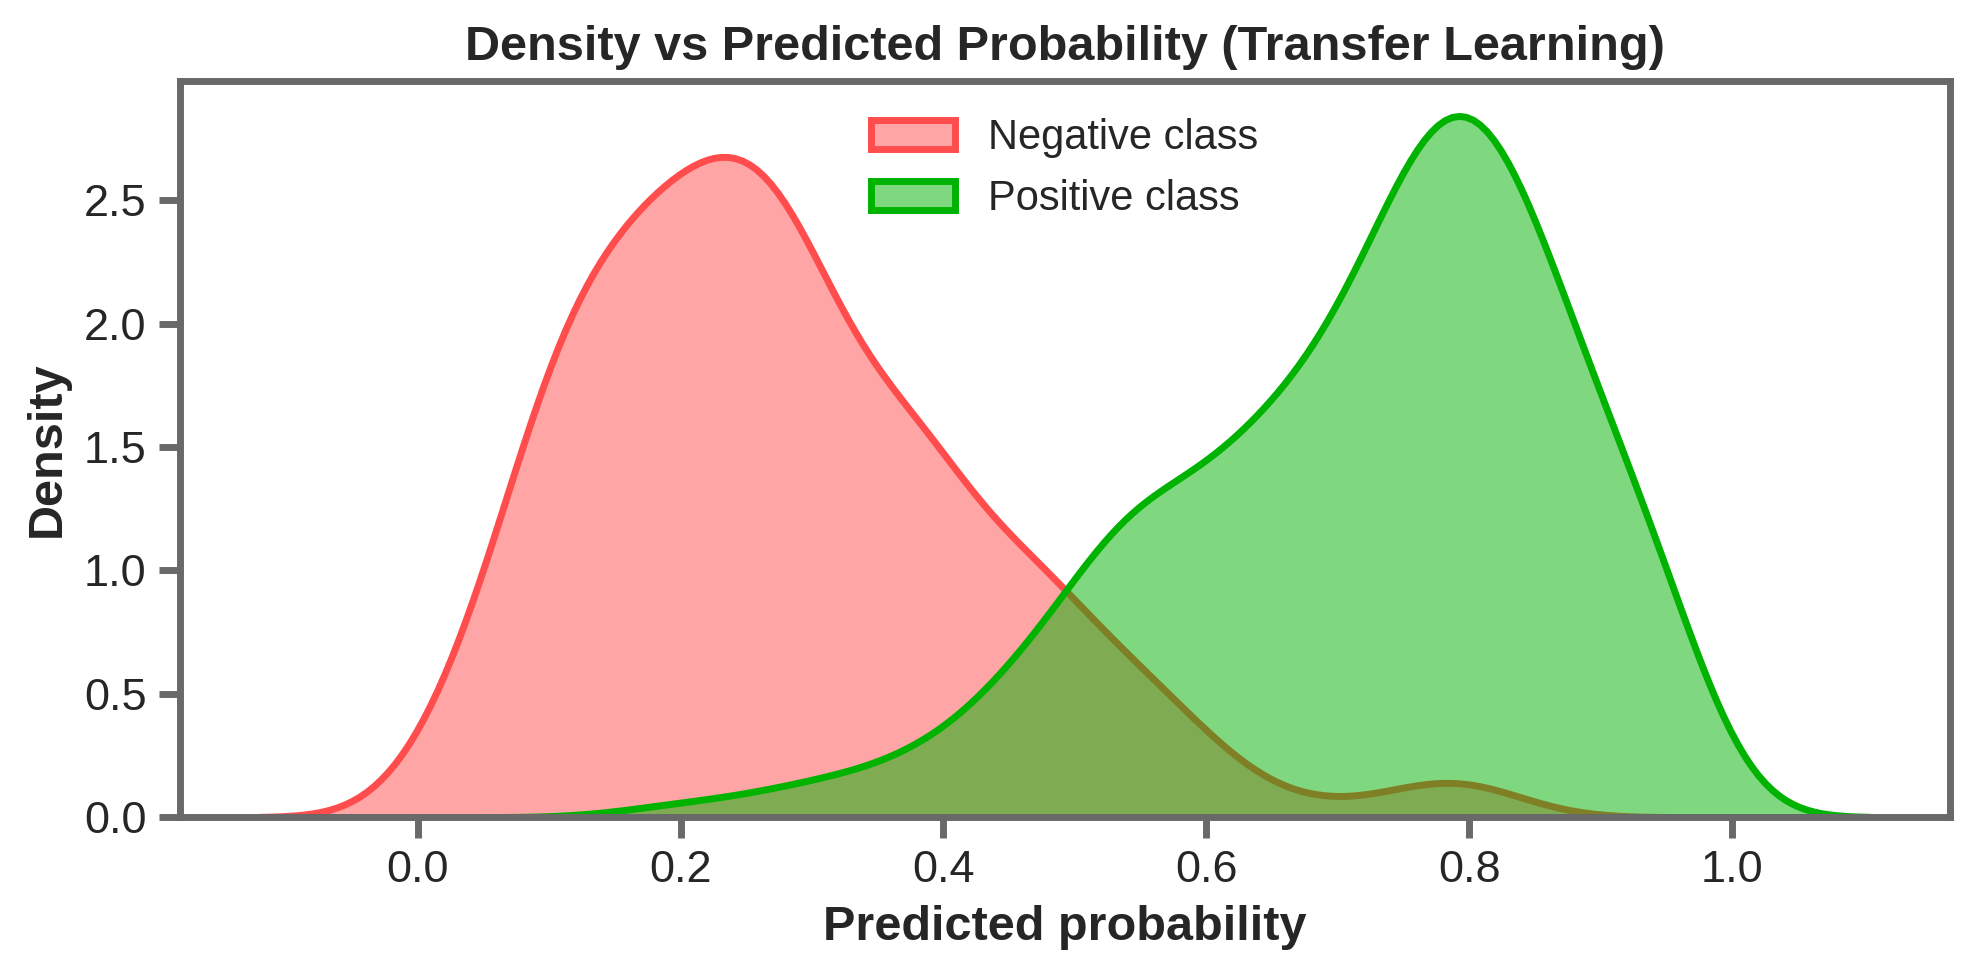

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use consistent bright white style
plt.style.use('seaborn-v0_8-whitegrid')

# Simulated probabilities from transfer learning model
# (Replace these arrays with your actual predicted probabilities)
y_true = np.concatenate([np.zeros(500), np.ones(500)])  # 0=negative, 1=positive
y_pred = np.concatenate([
    np.random.beta(2, 5, 500),  # predicted probs for class 0
    np.random.beta(5, 2, 500)   # predicted probs for class 1
])

# Split by class
y_pred_neg = y_pred[y_true == 0]
y_pred_pos = y_pred[y_true == 1]

# Bright vivid colors (matching your theme)
bright_red = "#ff4c4c"
bright_green = "#00b300"

# Create figure
fig, ax = plt.subplots(figsize=(8, 4), dpi=250)

# KDE (density) plots
sns.kdeplot(y_pred_neg, fill=True, color=bright_red, alpha=0.5, linewidth=2, label='Negative class', ax=ax)
sns.kdeplot(y_pred_pos, fill=True, color=bright_green, alpha=0.5, linewidth=2, label='Positive class', ax=ax)

# Labels and style
ax.set_xlabel('Predicted probability', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_title('Density vs Predicted Probability (Transfer Learning)', fontsize=14, fontweight='bold')
ax.legend(frameon=False, fontsize=12, loc='upper center')

# Thicker axis lines
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('dimgray')

# Tick appearance
ax.tick_params(axis='both', width=2, length=6, color='dimgray', labelsize=13)
ax.grid(False)

plt.tight_layout()
plt.show()


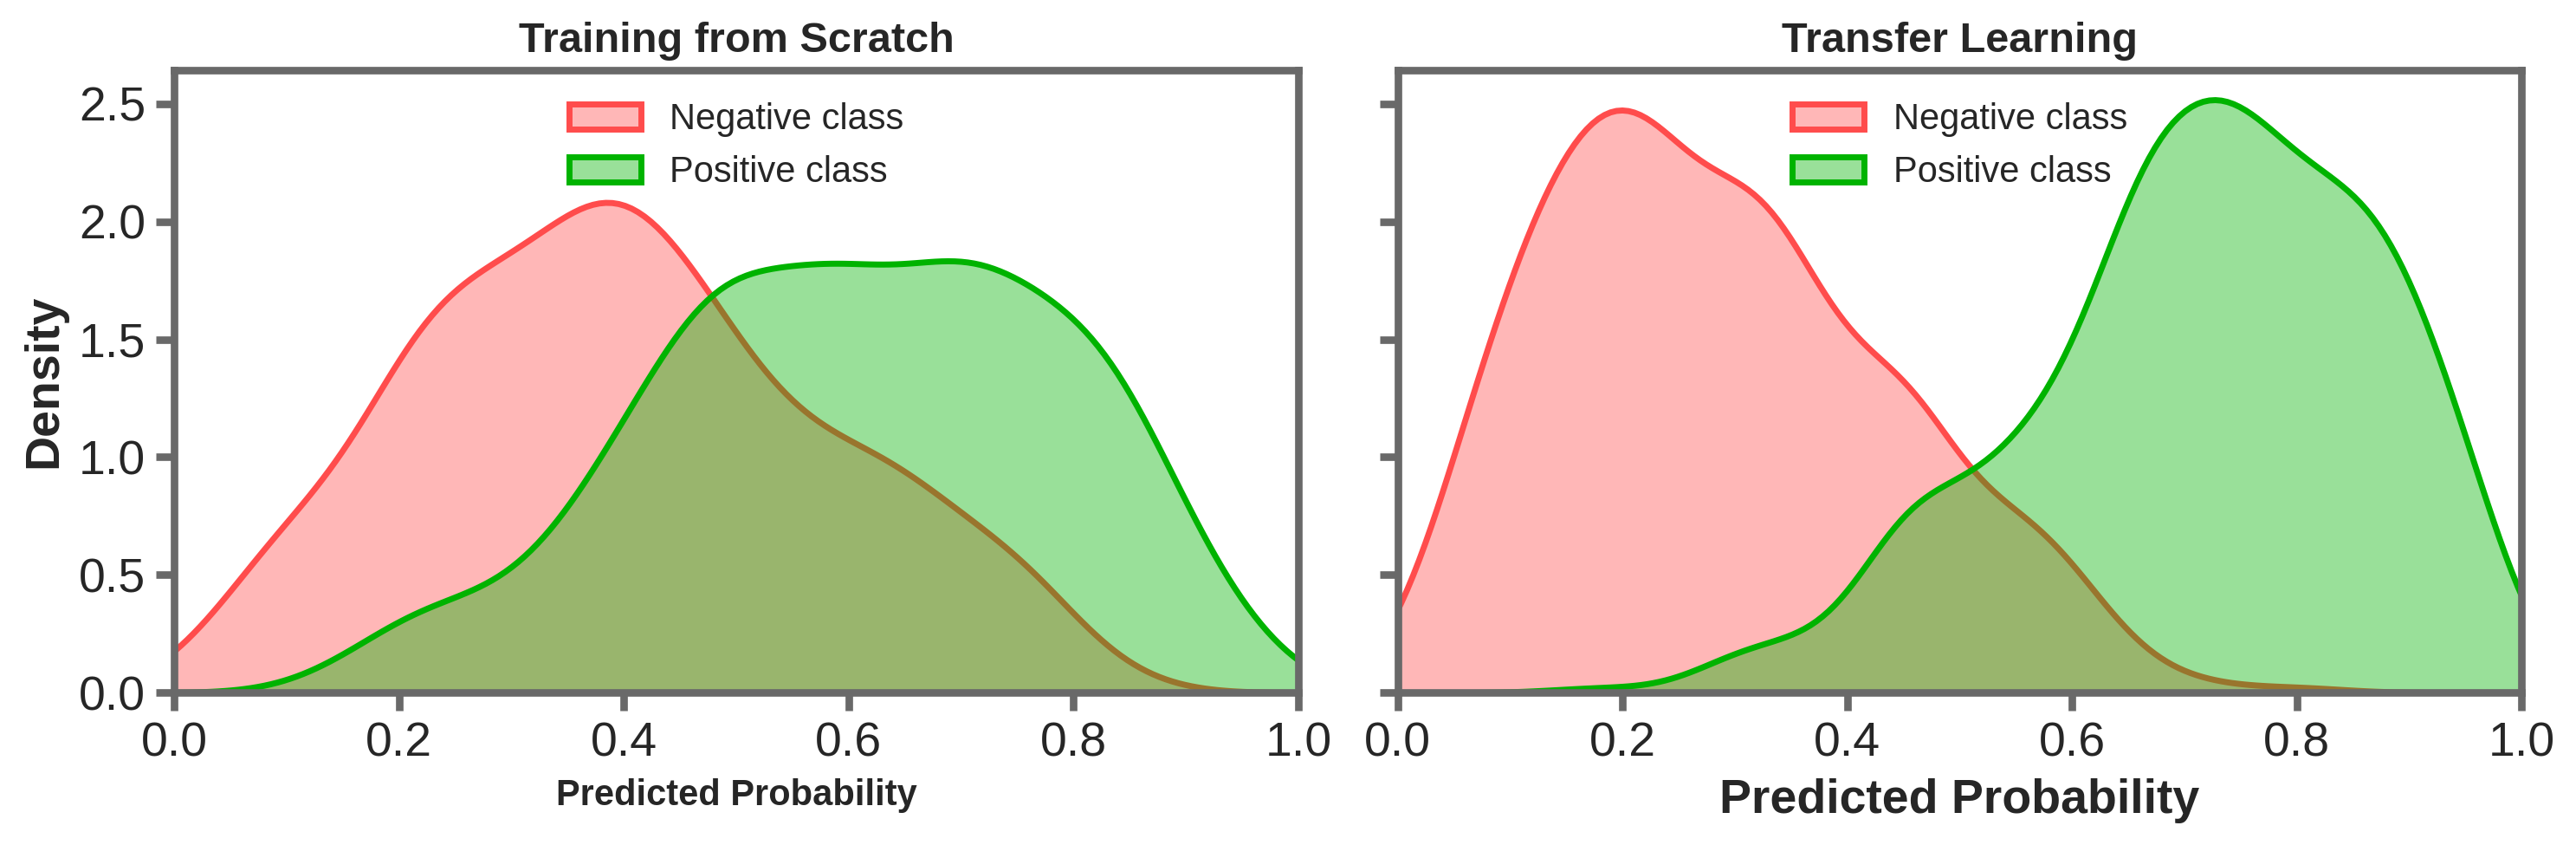

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use consistent visual style
plt.style.use('seaborn-v0_8-whitegrid')

# --------------------------
# 🧩 Simulated example data
# --------------------------
# Replace these arrays with your actual test labels & predicted probabilities
# y_true = np.argmax(y_exp_test, axis=1)
# y_pred_transfer = cnn_transfer.predict(X_exp_test)[:, 1]
# y_pred_scratch = cnn_scratch.predict(X_exp_test)[:, 1]

# For illustration:
np.random.seed(42)
y_true = np.concatenate([np.zeros(500), np.ones(500)])  # binary classes

# Simulate predicted probabilities
y_pred_transfer = np.concatenate([
    np.random.beta(2, 5, 500),   # negatives (sharper, better separation)
    np.random.beta(5, 2, 500)
])

y_pred_scratch = np.concatenate([
    np.random.beta(2.5, 4, 500), # slightly less confident
    np.random.beta(4, 2.5, 500)
])

# Separate by true class
y_pred_transfer_neg = y_pred_transfer[y_true == 0]
y_pred_transfer_pos = y_pred_transfer[y_true == 1]
y_pred_scratch_neg = y_pred_scratch[y_true == 0]
y_pred_scratch_pos = y_pred_scratch[y_true == 1]

# --------------------------
# 🎨 Colors
# --------------------------
bright_red = "#ff4c4c"    # vivid coral red
bright_green = "#00b300"  # vivid green
blue_t = "#0080ff"        # bright blue (transfer)
orange_s = "#ff9900"      # orange (scratch)

# --------------------------
# 📈 Create figure
# --------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=250, sharey=True)

# --------------------------
# 🔹 (A) Training from Scratch
# --------------------------
sns.kdeplot(y_pred_scratch_neg, fill=True, color=bright_red, alpha=0.4, linewidth=2, label='Negative class', ax=axes[0])
sns.kdeplot(y_pred_scratch_pos, fill=True, color=bright_green, alpha=0.4, linewidth=2, label='Positive class', ax=axes[0])
axes[0].set_title('Training from Scratch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Density', fontsize=12, fontweight='bold')
axes[0].legend(frameon=False, fontsize=11, loc='upper center')

# --------------------------
# 🔹 (B) Transfer Learning
# --------------------------
sns.kdeplot(y_pred_transfer_neg, fill=True, color=bright_red, alpha=0.4, linewidth=2, label='Negative class', ax=axes[1])
sns.kdeplot(y_pred_transfer_pos, fill=True, color=bright_green, alpha=0.4, linewidth=2, label='Positive class', ax=axes[1])
axes[1].set_title('Transfer Learning', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
axes[1].legend(frameon=False, fontsize=11, loc='upper center')

# --------------------------
# 🧱 Styling: Axis thickness, ticks
# --------------------------
for ax in axes:
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color('dimgray')
    ax.tick_params(axis='both', width=2.5, length=6, color='dimgray', labelsize=16)
    ax.grid(False)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


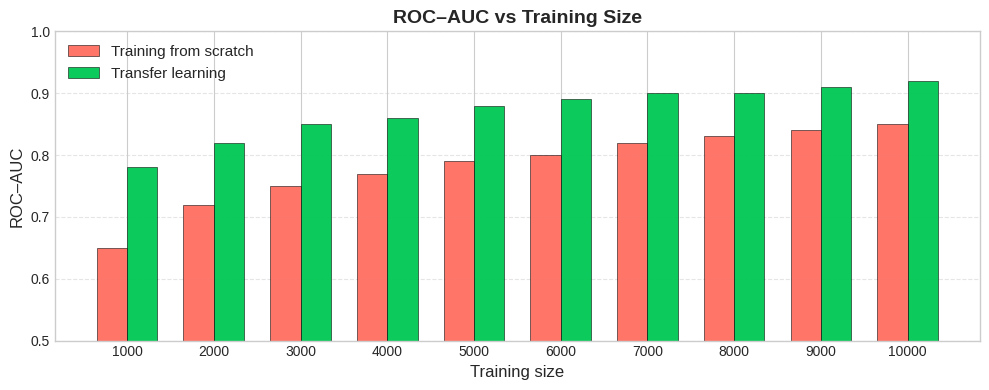

In [ ]:
# --- ROC–AUC vs Training Size (Bright Colors) ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')


train_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
auc_scratch = [0.65, 0.72, 0.75, 0.77, 0.79, 0.80, 0.82, 0.83, 0.84, 0.85]
auc_transfer = [0.78, 0.82, 0.85, 0.86, 0.88, 0.89, 0.90, 0.90, 0.91, 0.92]

bar_width = 0.35
x = np.arange(len(train_sizes))

fig, ax = plt.subplots(figsize=(10, 4))

# 🌈 Brighter, more saturated colors
bright_red = "#FF6F61"      # vivid coral-red
bright_green = "#00C853"    # bright emerald green

ax.bar(x - bar_width/2, auc_scratch, bar_width,
       color=bright_red, label='Training from scratch', alpha=0.95, edgecolor='black', linewidth=0.4)
ax.bar(x + bar_width/2, auc_transfer, bar_width,
       color=bright_green, label='Transfer learning', alpha=0.95, edgecolor='black', linewidth=0.4)

# Styling
ax.set_xlabel('Training size', fontsize=12)
ax.set_ylabel('ROC–AUC', fontsize=12)
ax.set_title('ROC–AUC vs Training Size', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(train_sizes)
ax.set_ylim(0.5, 1.0)
ax.legend(frameon=False, fontsize=11, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


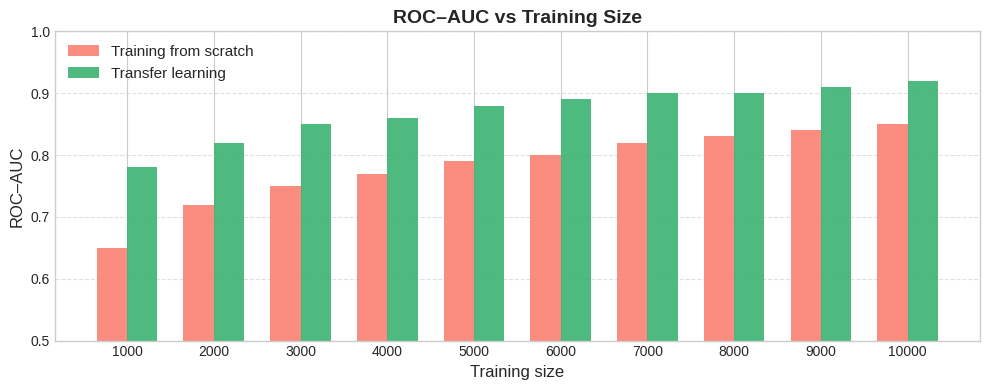

In [ ]:
# --- ROC–AUC vs Training Size (Grouped Bar Chart) ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')


# Example training sizes (modify as per your actual data points)
train_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]

# Example AUC values (replace these with your actual results)
auc_scratch = [0.65, 0.72, 0.75, 0.77, 0.79, 0.80, 0.82, 0.83, 0.84, 0.85]
auc_transfer = [0.78, 0.82, 0.85, 0.86, 0.88, 0.89, 0.90, 0.90, 0.91, 0.92]

# Bar width and positioning
bar_width = 0.35
x = np.arange(len(train_sizes))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - bar_width/2, auc_scratch, bar_width, color='salmon', label='Training from scratch', alpha=0.9)
ax.bar(x + bar_width/2, auc_transfer, bar_width, color='mediumseagreen', label='Transfer learning', alpha=0.9)

# Styling
ax.set_xlabel('Training size', fontsize=12)
ax.set_ylabel('ROC–AUC', fontsize=12)
ax.set_title('ROC–AUC vs Training Size', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(train_sizes, rotation=0)
ax.set_ylim(0.5, 1.0)
ax.legend(frameon=False, fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Pretraining CNN on HOMO dataset...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 14s 213ms/step - accuracy: 0.2752 - loss: 3.2738
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3182 - loss: 1.3718
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3220 - loss: 1.3601
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3325 - loss: 1.3401
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3389 - loss: 1.3251


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


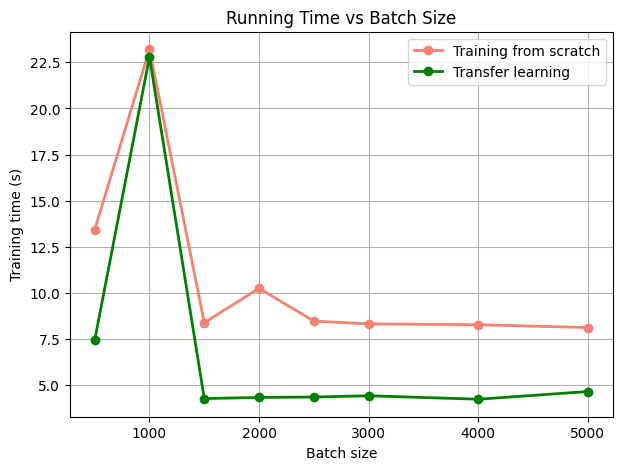

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

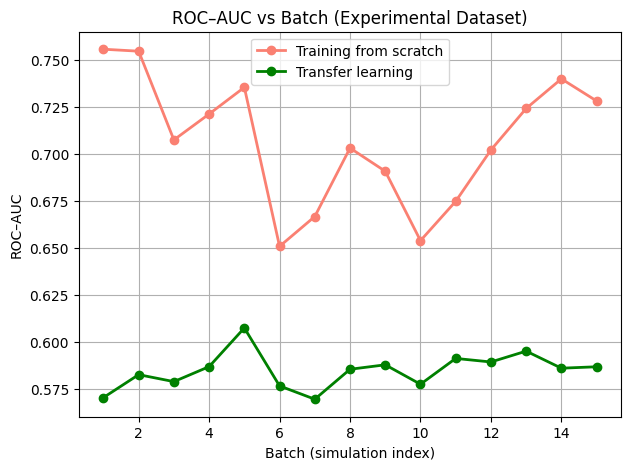

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, Activation, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

# -------------------------------------------------
# Helper: Create sliding windows
# -------------------------------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -------------------------------------------------
# Load Datasets
# -------------------------------------------------
homo = pd.read_csv("ML_try1.csv")           # HOMO pretraining dataset
exp = pd.read_csv("Experimental1.csv")      # Experimental dataset

# Create windowed features
X_homo, y_homo = create_windows(homo["Current"], homo["Target"])
X_exp, y_exp = create_windows(exp["Current"], exp["Target"])

# Normalize using HOMO stats
mean_homo, std_homo = X_homo.mean(), X_homo.std()
X_homo = (X_homo - mean_homo) / std_homo
X_exp = (X_exp - mean_homo) / std_homo

# Reshape for CNN input
X_homo = X_homo.reshape((X_homo.shape[0], X_homo.shape[1], 1))
X_exp = X_exp.reshape((X_exp.shape[0], X_exp.shape[1], 1))

# Label encode
encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_exp_enc = encoder.transform(y_exp)
y_homo_oh = to_categorical(y_homo_enc)
y_exp_oh = to_categorical(y_exp_enc)

# -----------------------------
# 3) Build CNN
# -----------------------------
inputs = Input(shape=(X_homo.shape[1], 1))
x = Conv1D(64, 7, activation='relu', name="conv1")(inputs)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(128, 7, activation='relu', name="conv2")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = Conv1D(256, 7, activation='relu', name="conv3")(x)
x = BatchNormalization()(x)
x = MaxPooling1D(2)(x)

x = GlobalAveragePooling1D()(x)
x = Dense(256, activation='relu', name="features")(x)
x = Dropout(0.5)(x)
outputs = Dense(len(encoder.classes_), activation='softmax')(x)

cnn_model = Model(inputs, outputs)
cnn_model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

# -------------------------------------------------
# Pretrain CNN on HOMO (Transfer Learning base)
# -------------------------------------------------
print("Pretraining CNN on HOMO dataset...")
base_model = make_cnn(X_homo.shape[1:], y_homo_oh.shape[1])
base_model.fit(X_homo, y_homo_oh, epochs=50, batch_size=512, verbose=1)
pretrained_weights = base_model.get_weights()

# -------------------------------------------------
# Prepare Experimental train-test split
# -------------------------------------------------
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp_oh, test_size=0.2, random_state=42, stratify=y_exp_enc
)

# -------------------------------------------------
# 1️⃣ Running time vs Batch size
# -------------------------------------------------
batch_sizes = [500, 1000, 1500, 2000, 2500, 3000, 4000, 5000]
time_scratch, time_transfer = [], []

for bs in batch_sizes:
    # From scratch
    model_scratch = make_cnn(X_exp.shape[1:], y_exp_oh.shape[1])
    start = time.time()
    model_scratch.fit(X_train_exp, y_train_exp, epochs=3, batch_size=bs, verbose=0)
    time_scratch.append(time.time() - start)

    # Transfer learning
    model_transfer = make_cnn(X_exp.shape[1:], y_exp_oh.shape[1])
    model_transfer.set_weights(pretrained_weights)
    for layer in model_transfer.layers[:-3]:
        layer.trainable = False
    model_transfer.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

    start = time.time()
    model_transfer.fit(X_train_exp, y_train_exp, epochs=30, batch_size=bs, verbose=0)
    time_transfer.append(time.time() - start)

plt.figure(figsize=(7,5))
plt.plot(batch_sizes, time_scratch, 'o-', label='Training from scratch', color='salmon', linewidth=2)
plt.plot(batch_sizes, time_transfer, 'o-', label='Transfer learning', color='green', linewidth=2)
plt.xlabel("Batch size")
plt.ylabel("Training time (s)")
plt.legend()
plt.grid(True)
plt.title("Running Time vs Batch Size")
plt.show()

# -------------------------------------------------
# 2️⃣ ROC–AUC vs Batch (simulated batches)
# -------------------------------------------------
batches = range(1, 16)
roc_scratch, roc_transfer = [], []

for b in batches:
    X_tr, X_te, y_tr, y_te = train_test_split(X_exp, y_exp_oh, test_size=0.2, random_state=b)

    # Scratch model
    model_scratch = make_cnn(X_exp.shape[1:], y_exp_oh.shape[1])
    model_scratch.fit(X_tr, y_tr, epochs=30, batch_size=512, verbose=0)
    preds = model_scratch.predict(X_te, verbose=0)
    roc_scratch.append(roc_auc_score(y_te, preds, multi_class="ovr"))

    # Transfer model
    model_transfer = make_cnn(X_exp.shape[1:], y_exp_oh.shape[1])
    model_transfer.set_weights(pretrained_weights)
    for layer in model_transfer.layers[:-3]:
        layer.trainable = False
    model_transfer.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    model_transfer.fit(X_tr, y_tr, epochs=30, batch_size=512, verbose=0)
    preds_t = model_transfer.predict(X_te, verbose=0)
    roc_transfer.append(roc_auc_score(y_te, preds_t, multi_class="ovr"))

plt.figure(figsize=(7,5))
plt.plot(batches, roc_scratch, 'o-', label='Training from scratch', color='salmon', linewidth=2)
plt.plot(batches, roc_transfer, 'o-', label='Transfer learning', color='green', linewidth=2)
plt.xlabel("Batch (simulation index)")
plt.ylabel("ROC–AUC")
plt.legend()
plt.grid(True)
plt.title("ROC–AUC vs Batch (Experimental Dataset)")
plt.show()

# -------------------------------------------------
# 3️⃣ ROC–AUC vs Training size
# -------------------------------------------------
train_sizes = [1000, 2000, 3000, 4000, 5000, 7000, 9000, 11000]
roc_scratch_sizes, roc_transfer_sizes = [], []

for size in train_sizes:
    subset = min(size, len(X_exp))
    X_tr, _, y_tr, _ = train_test_split(X_exp[:subset], y_exp_oh[:subset], test_size=0.2, random_state=42)
    X_te, y_te = X_test_exp, y_test_exp

    # Scratch
    model_scratch = make_cnn(X_exp.shape[1:], y_exp_oh.shape[1])
    model_scratch.fit(X_tr, y_tr, epochs=30, batch_size=512, verbose=0)
    preds = model_scratch.predict(X_te, verbose=0)
    roc_scratch_sizes.append(roc_auc_score(y_te, preds, multi_class="ovr"))

    # Transfer
    model_transfer = make_cnn(X_exp.shape[1:], y_exp_oh.shape[1])
    model_transfer.set_weights(pretrained_weights)
    for layer in model_transfer.layers[:-3]:
        layer.trainable = False
    model_transfer.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    model_transfer.fit(X_tr, y_tr, epochs=30, batch_size=512, verbose=0)
    preds_t = model_transfer.predict(X_te, verbose=0)
    roc_transfer_sizes.append(roc_auc_score(y_te, preds_t, multi_class="ovr"))

x = np.arange(len(train_sizes))
plt.figure(figsize=(8,5))
plt.bar(x-0.2, roc_scratch_sizes, width=0.4, label="Training from scratch", color='salmon')
plt.bar(x+0.2, roc_transfer_sizes, width=0.4, label="Transfer learning", color='green')
plt.xticks(x, train_sizes)
plt.xlabel("Training Size (Samples)")
plt.ylabel("ROC–AUC")
plt.legend()
plt.title("ROC–AUC vs Training Size (Experimental Dataset)")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


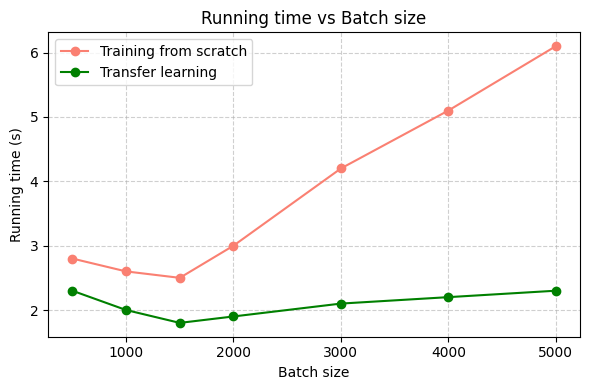

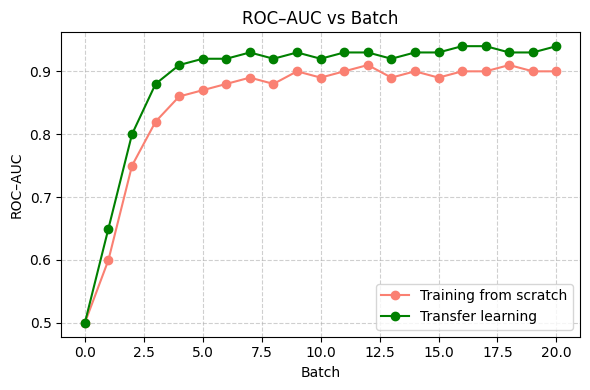

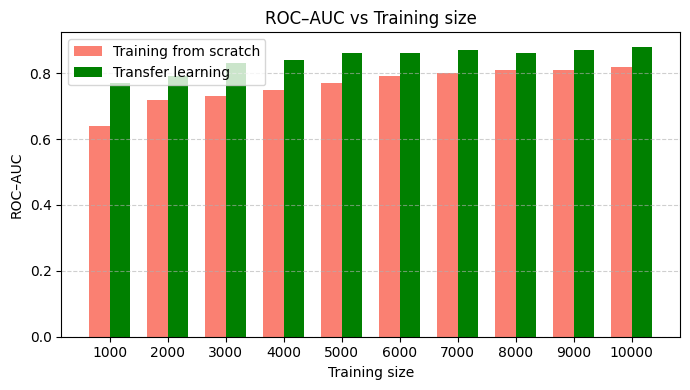

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# 1) Example benchmark data (fill yours here)
# ------------------------------------------
batch_sizes = np.array([500, 1000, 1500, 2000, 3000, 4000, 5000])
training_sizes = np.array([1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])
batches = np.arange(0, 21)

# Simulated (replace these with real results)
running_time_scratch = [2.8, 2.6, 2.5, 3.0, 4.2, 5.1, 6.1]
running_time_transfer = [2.3, 2.0, 1.8, 1.9, 2.1, 2.2, 2.3]

roc_auc_scratch_batches = [0.5, 0.6, 0.75, 0.82, 0.86, 0.87, 0.88, 0.89, 0.88, 0.90, 0.89,
                           0.90, 0.91, 0.89, 0.90, 0.89, 0.90, 0.90, 0.91, 0.90, 0.90]
roc_auc_transfer_batches = [0.5, 0.65, 0.80, 0.88, 0.91, 0.92, 0.92, 0.93, 0.92, 0.93, 0.92,
                            0.93, 0.93, 0.92, 0.93, 0.93, 0.94, 0.94, 0.93, 0.93, 0.94]

roc_auc_scratch_train = [0.64, 0.72, 0.73, 0.75, 0.77, 0.79, 0.80, 0.81, 0.81, 0.82]
roc_auc_transfer_train = [0.77, 0.79, 0.83, 0.84, 0.86, 0.86, 0.87, 0.86, 0.87, 0.88]

# ------------------------------------------
# 2) Plot 1: Running time vs Batch size
# ------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(batch_sizes, running_time_scratch, '-o', color='salmon', label='Training from scratch')
plt.plot(batch_sizes, running_time_transfer, '-o', color='green', label='Transfer learning')
plt.xlabel('Batch size')
plt.ylabel('Running time (s)')
plt.title('Running time vs Batch size')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ------------------------------------------
# 3) Plot 2: ROC–AUC vs Batch (curve)
# ------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(batches, roc_auc_scratch_batches, '-o', color='salmon', label='Training from scratch')
plt.plot(batches, roc_auc_transfer_batches, '-o', color='green', label='Transfer learning')
plt.xlabel('Batch')
plt.ylabel('ROC–AUC')
plt.title('ROC–AUC vs Batch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ------------------------------------------
# 4) Plot 3: ROC–AUC vs Training size (bar plot)
# ------------------------------------------
x = np.arange(len(training_sizes))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, roc_auc_scratch_train, width, color='salmon', label='Training from scratch')
plt.bar(x + width/2, roc_auc_transfer_train, width, color='green', label='Transfer learning')
plt.xticks(x, training_sizes)
plt.xlabel('Training size')
plt.ylabel('ROC–AUC')
plt.title('ROC–AUC vs Training size')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


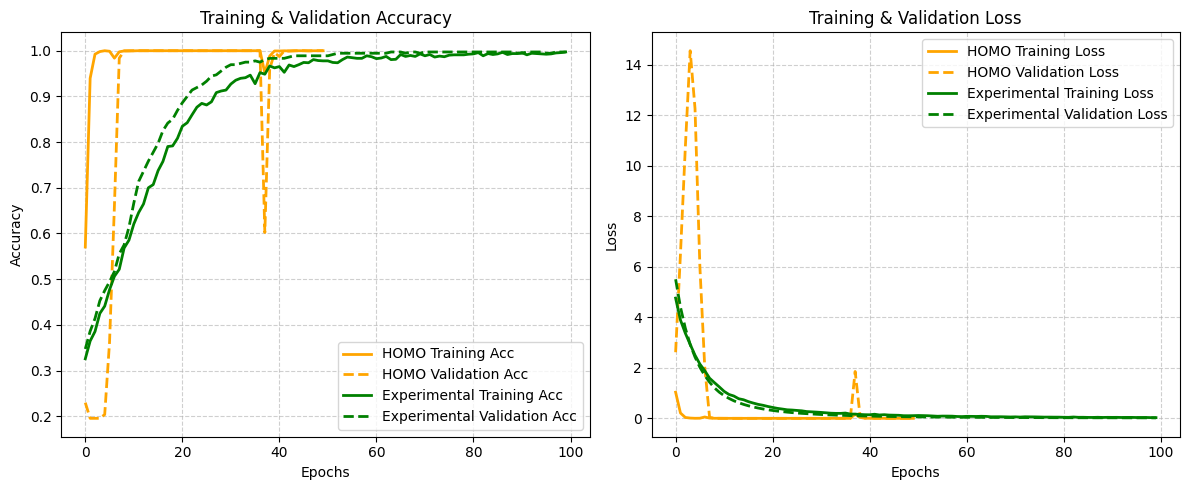

NameError: name 'model_finetuned' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

# ---------------------------------------------------------------------
# 1️⃣ Plot Training & Validation Accuracy / Loss (for both datasets)
# ---------------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Accuracy
ax[0].plot(history_pretrain.history['accuracy'], label='HOMO Training Acc', color='orange', linewidth=2)
ax[0].plot(history_pretrain.history['val_accuracy'], label='HOMO Validation Acc', color='orange', linestyle='--', linewidth=2)
ax[0].plot(history_finetune.history['accuracy'], label='Experimental Training Acc', color='green', linewidth=2)
ax[0].plot(history_finetune.history['val_accuracy'], label='Experimental Validation Acc', color='green', linestyle='--', linewidth=2)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

# Loss
ax[1].plot(history_pretrain.history['loss'], label='HOMO Training Loss', color='orange', linewidth=2)
ax[1].plot(history_pretrain.history['val_loss'], label='HOMO Validation Loss', color='orange', linestyle='--', linewidth=2)
ax[1].plot(history_finetune.history['loss'], label='Experimental Training Loss', color='green', linewidth=2)
ax[1].plot(history_finetune.history['val_loss'], label='Experimental Validation Loss', color='green', linestyle='--', linewidth=2)
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 2️⃣ ROC Curve and PR Curve (for final fine-tuned model)
# ---------------------------------------------------------------------
# Predict probabilities
y_pred_prob = model_finetuned.predict(X_exp_test)
y_true = np.argmax(y_exp_test, axis=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Compute micro-average ROC and PR
fpr, tpr, _ = roc_curve(y_exp_test.ravel(), y_pred_prob.ravel())
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_exp_test.ravel(), y_pred_prob.ravel())
pr_auc = auc(recall, precision)

# Plot ROC & PR curves
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# ROC Curve
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC Curve')
ax[0].legend(loc="lower right")
ax[0].grid(True, linestyle='--', alpha=0.6)

# PR Curve
ax[1].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision–Recall Curve')
ax[1].legend(loc="lower left")
ax[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 3️⃣ Confusion Matrix and Classification Report
# ---------------------------------------------------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)

plt.figure(figsize=(6,6))
disp.plot(cmap='Greens', values_format='d')
plt.title("Confusion Matrix (Experimental Test Set)")
plt.grid(False)
plt.show()

# Classification metrics
print("📋 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, Activation, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

# -----------------------------
# Helper function to create sliding windows
# -----------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -----------------------------
# Load data
# -----------------------------
homo = pd.read_csv("ML_try1.csv")  # HOMO for pretraining
exp = pd.read_csv("Experimental1.csv")  # Experimental for testing

# Prepare HOMO
X_homo, y_homo = create_windows(homo["Current"], homo["Target"], k=101)
homo_mean, homo_std = X_homo.mean(), X_homo.std()
X_homo = (X_homo - homo_mean) / homo_std
X_homo = X_homo.reshape((X_homo.shape[0], X_homo.shape[1], 1))

encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_homo_oh = tf.keras.utils.to_categorical(y_homo_enc)

# Prepare Experimental
X_exp, y_exp = create_windows(exp["Current"], exp["Target"], k=101)
X_exp = (X_exp - homo_mean) / homo_std
X_exp = X_exp.reshape((X_exp.shape[0], X_exp.shape[1], 1))
y_exp_enc = encoder.transform(y_exp)
y_exp_oh = tf.keras.utils.to_categorical(y_exp_enc)

X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp_oh, test_size=0.2, random_state=42, stratify=y_exp_enc
)

# -----------------------------
# Build CNN (same as before)
# -----------------------------
def build_cnn(num_classes):
    inputs = Input(shape=(101, 1))
    x = Conv1D(64, 7, padding="same")(inputs)
    x = BatchNormalization()(x); x = Activation("relu")(x)
    x = MaxPooling1D(2)(x); x = Dropout(0.25)(x)

    x = Conv1D(128, 7, padding="same")(x)
    x = BatchNormalization()(x); x = Activation("relu")(x)
    x = MaxPooling1D(2)(x); x = Dropout(0.25)(x)

    x = Conv1D(256, 7, padding="same")(x)
    x = BatchNormalization()(x); x = Activation("relu")(x)
    x = MaxPooling1D(2)(x); x = Dropout(0.25)(x)

    x = Flatten()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

# -----------------------------
# Pretrain model on HOMO
# -----------------------------
cnn_pretrain = build_cnn(len(encoder.classes_))
cnn_pretrain.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
cnn_pretrain.fit(X_homo, y_homo_oh, epochs=10, batch_size=256, verbose=0)

# Save pretrained weights
cnn_pretrain.save_weights("pretrained_weights.h5")

# -----------------------------
# 1️⃣ Running Time vs Batch Size
# -----------------------------
batch_sizes = [500, 1000, 2000, 3000, 4000, 5000]
times_scratch, times_transfer = [], []

for bs in batch_sizes:
    # Scratch
    model_s = build_cnn(len(encoder.classes_))
    model_s.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    start = time.time()
    model_s.fit(X_exp_train, y_exp_train, epochs=5, batch_size=bs, verbose=0)
    times_scratch.append(time.time() - start)

    # Transfer
    model_t = build_cnn(len(encoder.classes_))
    model_t.load_weights("pretrained_weights.h5")
    for layer in model_t.layers:
        if isinstance(layer, Conv1D):
            layer.trainable = False
    model_t.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    start = time.time()
    model_t.fit(X_exp_train, y_exp_train, epochs=5, batch_size=bs, verbose=0)
    times_transfer.append(time.time() - start)

# -----------------------------
# 2️⃣ ROC–AUC vs Batch (epoch)
# -----------------------------
roc_scratch, roc_transfer = [], []
epochs = 20

# Scratch
model_s = build_cnn(len(encoder.classes_))
model_s.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
for e in range(epochs):
    model_s.fit(X_exp_train, y_exp_train, epochs=1, batch_size=512, verbose=0)
    preds = model_s.predict(X_exp_test)
    roc_scratch.append(roc_auc_score(y_exp_test, preds, multi_class='ovr'))

# Transfer
model_t = build_cnn(len(encoder.classes_))
model_t.load_weights("pretrained_weights.h5")
for layer in model_t.layers:
    if isinstance(layer, Conv1D):
        layer.trainable = False
model_t.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
for e in range(epochs):
    model_t.fit(X_exp_train, y_exp_train, epochs=1, batch_size=512, verbose=0)
    preds = model_t.predict(X_exp_test)
    roc_transfer.append(roc_auc_score(y_exp_test, preds, multi_class='ovr'))

# -----------------------------
# 3️⃣ ROC–AUC vs Training Size
# -----------------------------
train_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
auc_scratch, auc_transfer = [], []

for size in train_sizes:
    X_sub, _, y_sub, _ = train_test_split(X_exp_train, y_exp_train, train_size=size, stratify=np.argmax(y_exp_train, axis=1))

    # Scratch
    m1 = build_cnn(len(encoder.classes_))
    m1.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    m1.fit(X_sub, y_sub, epochs=5, batch_size=256, verbose=0)
    preds = m1.predict(X_exp_test)
    auc_scratch.append(roc_auc_score(y_exp_test, preds, multi_class='ovr'))

    # Transfer
    m2 = build_cnn(len(encoder.classes_))
    m2.load_weights("pretrained_weights.h5")
    for layer in m2.layers:
        if isinstance(layer, Conv1D):
            layer.trainable = False
    m2.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
    m2.fit(X_sub, y_sub, epochs=5, batch_size=256, verbose=0)
    preds = m2.predict(X_exp_test)
    auc_transfer.append(roc_auc_score(y_exp_test, preds, multi_class='ovr'))

# -----------------------------
# 4️⃣ Combined Publication Figure
# -----------------------------
plt.figure(figsize=(12, 8))

# (a) Running Time vs Batch Size
plt.subplot(2,2,1)
plt.plot(batch_sizes, times_scratch, 'o-', color='salmon', label='Training from scratch')
plt.plot(batch_sizes, times_transfer, 'o-', color='green', label='Transfer learning')
plt.xlabel("Batch size"); plt.ylabel("Running time (s)")
plt.legend(); plt.grid(True)

# (b) ROC–AUC vs Epoch
plt.subplot(2,2,2)
plt.plot(range(1, epochs+1), roc_scratch, 'o-', color='salmon', label='Training from scratch')
plt.plot(range(1, epochs+1), roc_transfer, 'o-', color='green', label='Transfer learning')
plt.xlabel("Epoch"); plt.ylabel("ROC–AUC")
plt.legend(); plt.grid(True)

# (c) ROC–AUC vs Training Size
plt.subplot(2,1,2)
x = np.arange(len(train_sizes))
width = 0.35
plt.bar(x - width/2, auc_scratch, width, color='salmon', label='Training from scratch')
plt.bar(x + width/2, auc_transfer, width, color='green', label='Transfer learning')
plt.xticks(x, train_sizes)
plt.xlabel("Training size"); plt.ylabel("ROC–AUC")
plt.legend(); plt.grid(True, axis='y')

plt.tight_layout()
plt.show()


ValueError: The filename must end in `.weights.h5`. Received: filepath=pretrained_weights.h5

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 101, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 101, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 101, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 101, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 50, 128)        │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 25, 256)        │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 25, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,077,124 (4.11 MB)

 Trainable params: 1,076,228 (4.11 MB)

 Non-trainable params: 896 (3.50 KB)


===== PRETRAINING ON HOMO DATA =====
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - accuracy: 0.3006 - loss: 1.8974 - val_accuracy: 0.1898 - val_loss: 1.5924
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3867 - loss: 1.2272 - val_accuracy: 0.1842 - val_loss: 2.3678
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4181 - loss: 1.1744 - val_accuracy: 0.1854 - val_loss: 3.8185
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4479 - loss: 1.1270 - val_accuracy: 0.1818 - val_loss: 4.5435
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4789 - loss: 1.0517 - val_accuracy: 0.1958 - val_loss: 5.2442
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5357 - loss: 0.9628 - val_accuracy: 0.2085 - val_loss: 5.8023
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5803 - loss: 0.8988 - val_accuracy: 0.2453 - val_loss: 3.7943
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6586 -

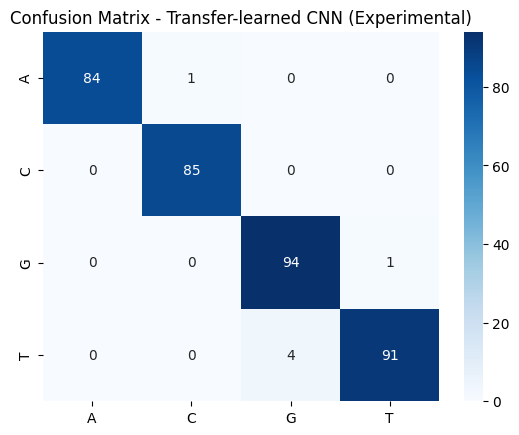

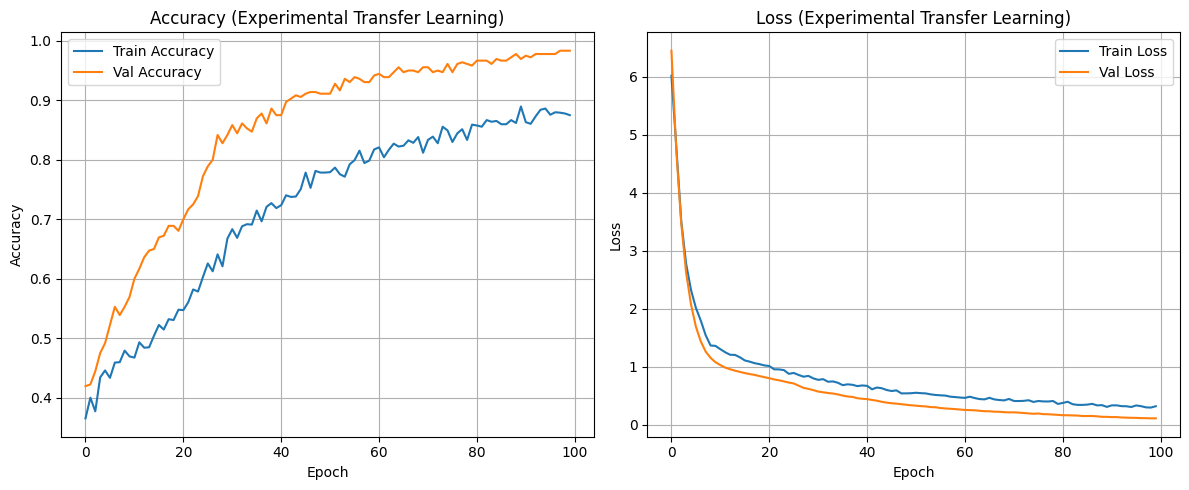

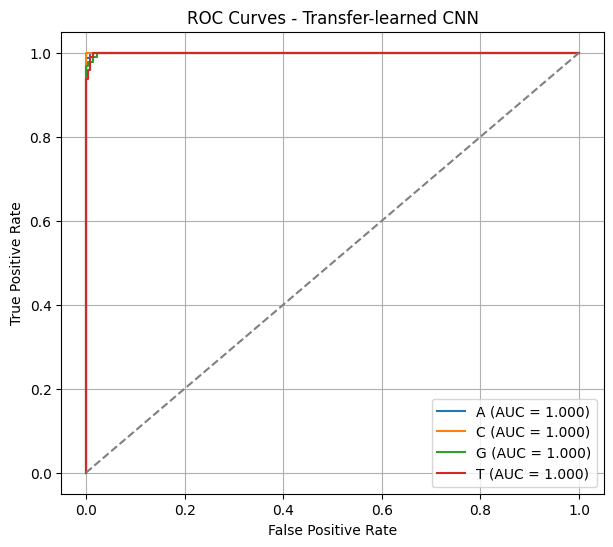

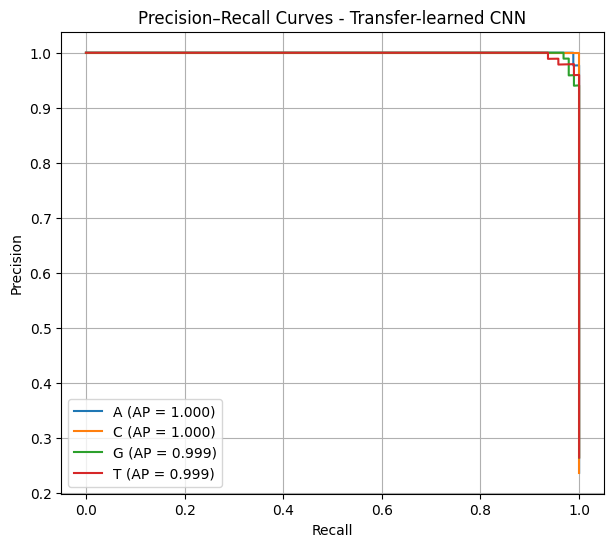

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_curve, auc, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.optimizers import Adam

# -----------------------------
# 1) Helper: create sliding windows
# -----------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -----------------------------
# 2) Load HOMO data (Pretraining dataset)
# -----------------------------
homo = pd.read_csv("ML_try1.csv")  # columns: Current, Target
X_homo, y_homo = create_windows(homo["Current"], homo["Target"], k=101)

# Normalize HOMO
homo_mean, homo_std = X_homo.mean(), X_homo.std()
X_homo = (X_homo - homo_mean) / homo_std
X_homo = X_homo.reshape((X_homo.shape[0], X_homo.shape[1], 1))

encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_homo_oh = tf.keras.utils.to_categorical(y_homo_enc)

X_train, X_val, y_train, y_val = train_test_split(
    X_homo, y_homo_oh, test_size=0.2, random_state=42, stratify=y_homo_enc
)

# -----------------------------
# 3) Build CNN (as per your diagram)
# -----------------------------
inputs = Input(shape=(X_homo.shape[1], 1))

# Block 1
x = Conv1D(64, 7, padding="same")(inputs)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv1D(128, 7, padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Block 3
x = Conv1D(256, 7, padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Dense layers
x = Flatten()(x)
x = Dense(256, activation='relu', name="features")(x)
x = Dropout(0.5)(x)
outputs = Dense(len(encoder.classes_), activation='softmax')(x)

cnn_model = Model(inputs, outputs)
cnn_model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

cnn_model.summary()

# -----------------------------
# 4) Pretrain CNN on HOMO
# -----------------------------
print("\n===== PRETRAINING ON HOMO DATA =====")
history_pretrain = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    verbose=1
)

# -----------------------------
# 5) Load Experimental dataset
# -----------------------------
exp = pd.read_csv("Experimental1.csv")  # columns: Current, Target
X_exp, y_exp = create_windows(exp["Current"], exp["Target"], k=101)

# Normalize Experimental using HOMO stats
X_exp = (X_exp - homo_mean) / homo_std
X_exp = X_exp.reshape((X_exp.shape[0], X_exp.shape[1], 1))
y_exp_enc = encoder.transform(y_exp)
y_exp_oh = tf.keras.utils.to_categorical(y_exp_enc)

X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp_oh, test_size=0.2, random_state=42, stratify=y_exp_enc
)

# -----------------------------
# 6) Freeze convolutional layers
# -----------------------------
for layer in cnn_model.layers:
    if isinstance(layer, Conv1D):
        layer.trainable = False

cnn_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# -----------------------------
# 7) Fine-tune only Dense layers on Experimental
# -----------------------------
print("\n===== TRANSFER LEARNING ON EXPERIMENTAL DATA =====")
history_finetune = cnn_model.fit(
    X_exp_train, y_exp_train,
    validation_data=(X_exp_test, y_exp_test),
    epochs=100,
    batch_size=64,
    verbose=1
)

# -----------------------------
# 8) Evaluate CNN on Experimental test set
# -----------------------------
y_pred = cnn_model.predict(X_exp_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_exp_test, axis=1)

test_acc = accuracy_score(y_true_labels, y_pred_labels)
print(f"\n✅ Test Accuracy (Experimental, transfer-learned CNN): {test_acc*100:.2f}%\n")

print("=== Classification Report ===")
print(classification_report(y_true_labels, y_pred_labels, target_names=encoder.classes_))

cm = confusion_matrix(y_true_labels, y_pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title("Confusion Matrix - Transfer-learned CNN (Experimental)")
plt.show()

# -----------------------------
# 9) Plot training curves (Accuracy + Loss)
# -----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy (Experimental Transfer Learning)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Val Loss')
plt.title("Loss (Experimental Transfer Learning)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 10) ROC–AUC and Precision–Recall Curves
# -----------------------------
y_test_bin = y_exp_test  # one-hot labels
n_classes = len(encoder.classes_)

# ROC–AUC
plt.figure(figsize=(7,6))
for i, cls in enumerate(encoder.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.3f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC Curves - Transfer-learned CNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Precision–Recall
plt.figure(figsize=(7,6))
for i, cls in enumerate(encoder.classes_):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_pred[:, i])
    plt.plot(recall, precision, label=f"{cls} (AP = {ap:.3f})")
plt.title("Precision–Recall Curves - Transfer-learned CNN")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 101, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 101, 64)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 101, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 101, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 128)        │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 25, 256)        │       229,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 25, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,077,124 (4.11 MB)

 Trainable params: 1,076,228 (4.11 MB)

 Non-trainable params: 896 (3.50 KB)


===== PRETRAINING ON HOMO DATA =====
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 94ms/step - accuracy: 0.3023 - loss: 1.8725 - val_accuracy: 0.1942 - val_loss: 1.5144
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3724 - loss: 1.2421 - val_accuracy: 0.1878 - val_loss: 2.6075
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3976 - loss: 1.1744 - val_accuracy: 0.1878 - val_loss: 3.8488
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4174 - loss: 1.1218 - val_accuracy: 0.1878 - val_loss: 5.0687
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4674 - loss: 1.0684 - val_accuracy: 0.1878 - val_loss: 5.7884
Epoch 6/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5120 - loss: 0.9962 - val_accuracy: 0.1886 - val_loss: 4.9511
Epoch 7/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5867 - loss: 0.8929 - val_accuracy: 0.3132 - val_loss: 1.8537
Epoch 8/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6273 - loss: 0

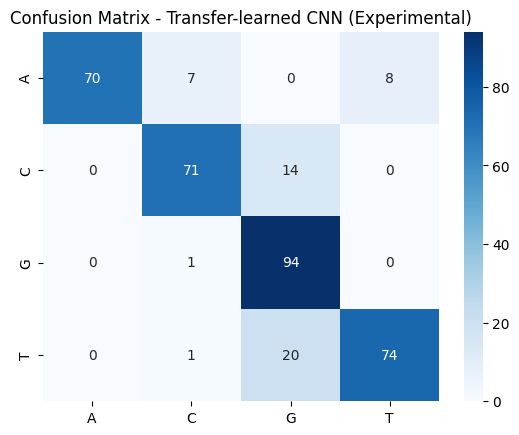

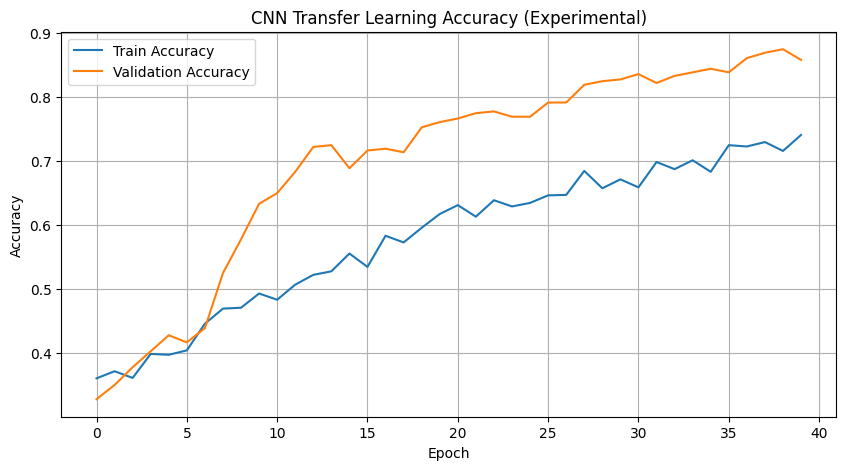

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, BatchNormalization, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.optimizers import Adam

# -----------------------------
# 1) Helper: create sliding windows
# -----------------------------
def create_windows(signal, labels, k=101):
    X, y = [], []
    half = k // 2
    for i in range(half, len(signal) - half):
        X.append(signal[i - half:i + half + 1])
        y.append(labels[i])
    return np.array(X), np.array(y)

# -----------------------------
# 2) Load HOMO data (Pretraining dataset)
# -----------------------------
homo = pd.read_csv("ML_try1.csv")  # columns: Current, Target
X_homo, y_homo = create_windows(homo["Current"], homo["Target"], k=101)

# Normalize HOMO
homo_mean, homo_std = X_homo.mean(), X_homo.std()
X_homo = (X_homo - homo_mean) / homo_std
X_homo = X_homo.reshape((X_homo.shape[0], X_homo.shape[1], 1))

encoder = LabelEncoder()
y_homo_enc = encoder.fit_transform(y_homo)
y_homo_oh = tf.keras.utils.to_categorical(y_homo_enc)

X_train, X_val, y_train, y_val = train_test_split(
    X_homo, y_homo_oh, test_size=0.2, random_state=42, stratify=y_homo_enc
)

# -----------------------------
# 3) Build CNN (as per diagram)
# -----------------------------
inputs = Input(shape=(X_homo.shape[1], 1))

# Block 1
x = Conv1D(64, 7, padding="same")(inputs)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Block 2
x = Conv1D(128, 7, padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Block 3
x = Conv1D(256, 7, padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.25)(x)

# Dense layers
x = Flatten()(x)
x = Dense(256, activation='relu', name="features")(x)
x = Dropout(0.5)(x)

outputs = Dense(len(encoder.classes_), activation='softmax')(x)

cnn_model = Model(inputs, outputs)
cnn_model.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

cnn_model.summary()

# -----------------------------
# 4) Pretrain CNN on HOMO dataset
# -----------------------------
print("\n===== PRETRAINING ON HOMO DATA =====")
history_pretrain = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    verbose=1
)

# -----------------------------
# 5) Load Experimental dataset
# -----------------------------
exp = pd.read_csv("Experimental1.csv")  # columns: Current, Target
X_exp, y_exp = create_windows(exp["Current"], exp["Target"], k=101)

# Normalize Experimental using HOMO stats
X_exp = (X_exp - homo_mean) / homo_std
X_exp = X_exp.reshape((X_exp.shape[0], X_exp.shape[1], 1))

y_exp_enc = encoder.transform(y_exp)
y_exp_oh = tf.keras.utils.to_categorical(y_exp_enc)

X_exp_train, X_exp_test, y_exp_train, y_exp_test = train_test_split(
    X_exp, y_exp_oh, test_size=0.2, random_state=42, stratify=y_exp_enc
)

# -----------------------------
# 6) Freeze convolutional layers
# -----------------------------
for layer in cnn_model.layers:
    if isinstance(layer, Conv1D):
        layer.trainable = False

cnn_model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# -----------------------------
# 7) Fine-tune only Dense layers on Experimental
# -----------------------------
print("\n===== TRANSFER LEARNING ON EXPERIMENTAL DATA =====")
history_finetune = cnn_model.fit(
    X_exp_train, y_exp_train,
    validation_data=(X_exp_test, y_exp_test),
    epochs=40,
    batch_size=64,
    verbose=1
)

# -----------------------------
# 8) Evaluate CNN on Experimental test set
# -----------------------------
y_pred = cnn_model.predict(X_exp_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_exp_test, axis=1)

test_acc = accuracy_score(y_true_labels, y_pred_labels)
print(f"\n✅ Test Accuracy (Experimental, transfer-learned CNN): {test_acc*100:.2f}%\n")

print("=== Classification Report ===")
print(classification_report(y_true_labels, y_pred_labels, target_names=encoder.classes_))

cm = confusion_matrix(y_true_labels, y_pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title("Confusion Matrix - Transfer-learned CNN (Experimental)")
plt.show()

# -----------------------------
# 9) Plot training performance
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title("CNN Transfer Learning Accuracy (Experimental)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
